# Corporate Default Prediction: Econometric vs. Machine-Learning Models

Companion notebook to the paper. It downloads the Polish Companies Bankruptcy data, re-estimates the classical Altman, Ohlson, and Zmijewski models, compares them against LASSO, random forest, and XGBoost under one unified evaluation protocol, and produces the figures used in the paper.

**Requirements:** `numpy pandas scipy scikit-learn statsmodels xgboost matplotlib`. Run the cells in order from top to bottom.

## 0. Setup

Install dependencies (skip if already present) and import the shared libraries used across the notebook.

In [1]:
# Uncomment the next line the first time you run this on a fresh machine.
# !pip install numpy pandas scipy scikit-learn statsmodels xgboost shap imbalanced-learn matplotlib

#!/usr/bin/env python3
# =============================================================================
# Corporate Default Prediction — consolidated analysis script
# Stages covered:
#   - Download + load the Polish Companies Bankruptcy data (Zieba 2016)
#   - Descriptive statistics for the five Altman ratios at horizon H1
#   - Stratified k-fold cross-validation harness + full metric battery
#   - Econometric baselines, LASSO, and the machine-learning models
#
# The script can be run top-to-bottom (`python bankruptcy_analysis.py`), or
# section-by-section in a notebook.
#
# Dependencies: numpy, pandas, scipy, scikit-learn, statsmodels, xgboost.
# =============================================================================

import io
import os
import warnings
import urllib.request
import zipfile

import numpy as np
import pandas as pd
from scipy.io import arff
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve,
)

warnings.filterwarnings("ignore")  # keep the console output readable

## 1. Load and prepare the Polish bankruptcy data

Download the dataset from the UCI repository, rename the 64 ratios to readable names, build the five prediction-horizon tables (H1-H5), add missingness indicators, and define the leakage-free preprocessing used throughout.

In [2]:
# -----------------------------------------------------------------------------
# 2.1  Download the raw data from UCI (skipped if files already present).
# -----------------------------------------------------------------------------
UCI_URL = (
    "https://archive.ics.uci.edu/static/public/365/"
    "polish+companies+bankruptcy+data.zip"
)
ARFF_FILES = [f"{y}year.arff" for y in range(1, 6)]

if all(os.path.exists(f) for f in ARFF_FILES):
    print("ARFF files already present — skipping download.")
else:
    print("Downloading Polish Companies Bankruptcy dataset from UCI...")
    with urllib.request.urlopen(UCI_URL) as response:
        zip_bytes = response.read()
    print(f"  Downloaded {len(zip_bytes) / 1e6:.1f} MB.")
    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:
        zf.extractall(".")
    print(f"  Extracted: {ARFF_FILES}")

# -----------------------------------------------------------------------------
# 2.2  Map the 64 raw attribute codes to readable ratio names.
# -----------------------------------------------------------------------------
RATIO_NAMES = {
    'Attr1':  'net_profit_TA',   'Attr2':  'TL_TA',          'Attr3':  'WC_TA',
    'Attr4':  'CA_STL',          'Attr5':  'qacid_days',     'Attr6':  'RE_TA',
    'Attr7':  'EBIT_TA',         'Attr8':  'BE_TL',          'Attr9':  'sales_TA',
    'Attr10': 'equity_TA',       'Attr11': 'GP_extra_fin_TA','Attr12': 'GP_STL',
    'Attr13': 'GP_DA_sales',     'Attr14': 'GP_int_TA',      'Attr15': 'TL_GP_DA_days',
    'Attr16': 'GP_DA_TL',        'Attr17': 'TA_TL',          'Attr18': 'GP_TA',
    'Attr19': 'GP_sales',        'Attr20': 'inv_sales_days', 'Attr21': 'sales_growth',
    'Attr22': 'OP_TA',           'Attr23': 'NP_sales',       'Attr24': 'GP3yr_TA',
    'Attr25': 'eq_minus_share_TA','Attr26':'NP_DA_TL',       'Attr27': 'OP_finexp',
    'Attr28': 'WC_FA',           'Attr29': 'log_TA',         'Attr30': 'TL_cash_sales',
    'Attr31': 'GP_int_sales',    'Attr32': 'CL_COGS_days',   'Attr33': 'OpEx_STL',
    'Attr34': 'OpEx_TL',         'Attr35': 'profit_sales_TA','Attr36': 'total_sales_TA',
    'Attr37': 'CA_inv_LTL',      'Attr38': 'const_cap_TA',   'Attr39': 'profit_sales',
    'Attr40': 'quick_ratio_STL', 'Attr41': 'TL_op_DA_monthly','Attr42':'OP_sales',
    'Attr43': 'AR_inv_days',     'Attr44': 'AR_sales_days',  'Attr45': 'NP_inv',
    'Attr46': 'CA_inv_STL',      'Attr47': 'inv_COGS_days',  'Attr48': 'EBITDA_TA',
    'Attr49': 'EBITDA_sales',    'Attr50': 'CA_TL',          'Attr51': 'STL_TA',
    'Attr52': 'STL_COGS_days',   'Attr53': 'eq_FA',          'Attr54': 'const_cap_FA',
    'Attr55': 'WC_level',        'Attr56': 'gross_margin',   'Attr57': 'liq_gap_sales',
    'Attr58': 'totcost_totsales','Attr59': 'LTL_equity',     'Attr60': 'sales_inv',
    'Attr61': 'sales_AR',        'Attr62': 'STL_sales_days', 'Attr63': 'sales_STL',
    'Attr64': 'sales_FA',
}
FEATURES = [RATIO_NAMES[f'Attr{i}'] for i in range(1, 65)]

# Canonical model subsets (used by the econometric baselines; defined here for reuse).
ALTMAN_5    = ['WC_TA', 'RE_TA', 'EBIT_TA', 'BE_TL', 'sales_TA']
OHLSON_7    = ['log_TA', 'TL_TA', 'WC_TA', 'CA_STL',
               'net_profit_TA', 'NP_DA_TL', 'equity_TA']
ZMIJEWSKI_3 = ['net_profit_TA', 'TL_TA', 'CA_STL']

# -----------------------------------------------------------------------------
# 2.3  File -> horizon mapping (UCI names are reversed; see paper Section 3.2).
# -----------------------------------------------------------------------------
FILE_TO_HORIZON = {
    '5year.arff': 'H1',   # 1-year-ahead: financials closest to the event
    '4year.arff': 'H2',
    '3year.arff': 'H3',
    '2year.arff': 'H4',
    '1year.arff': 'H5',   # 5-year-ahead: financials furthest from the event
}


def load_arff_file(path: str) -> pd.DataFrame:
    """Read one ARFF file, rename columns to ratio names, enforce dtypes."""
    data, _ = arff.loadarff(path)
    df = pd.DataFrame(data)
    df['class'] = df['class'].astype(int)
    df = df.rename(columns=RATIO_NAMES).rename(columns={'class': 'y'})
    for c in FEATURES:
        df[c] = df[c].astype(float)
    df['y'] = df['y'].astype('int8')
    return df


horizons: dict = {}
for fname, hkey in FILE_TO_HORIZON.items():
    df_h = load_arff_file(fname)
    df_h['horizon'] = hkey
    horizons[hkey] = df_h
horizons = {k: horizons[k] for k in sorted(horizons)}   # iterate H1..H5

# -----------------------------------------------------------------------------
# 2.4  Missingness indicators (informative-missingness; see paper Section 3.5).
# -----------------------------------------------------------------------------
MISSINGNESS_THRESHOLD = 0.01
miss_rates = pd.DataFrame({h: horizons[h][FEATURES].isna().mean() for h in horizons})
FLAG_FEATURES = sorted(
    miss_rates.index[(miss_rates >= MISSINGNESS_THRESHOLD).any(axis=1)].tolist()
)
MISS_INDS = [f'miss_{c}' for c in FLAG_FEATURES]
for h in horizons:
    for c in FLAG_FEATURES:
        horizons[h][f'miss_{c}'] = horizons[h][c].isna().astype('int8')


# -----------------------------------------------------------------------------
# 2.5  CV-safe preprocessing factory.
# -----------------------------------------------------------------------------
def make_preprocessor(num_cols, passthrough_cols=()):
    """
    Fresh (unfit) ColumnTransformer:
      - median-imputes `num_cols` (fit on the training fold only),
      - passes `passthrough_cols` through unchanged.
    Must be wrapped in a Pipeline and cloned per fold to avoid leakage.
    """
    return ColumnTransformer(
        transformers=[
            ('impute', SimpleImputer(strategy='median'), list(num_cols)),
            ('pass',   'passthrough',                    list(passthrough_cols)),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
    )


def build_preprocessor():
    """Backward-compatible: full 64 ratios imputed + 11 indicators passed through."""
    return make_preprocessor(FEATURES, MISS_INDS)


print("=" * 78)
print("DATA LOADED")
print("=" * 78)
_rows = []
for h, d in horizons.items():
    anymiss = d[FEATURES].isna().any(axis=1)
    _rows.append({
        'horizon': h, 'n': len(d), 'bankrupt': int(d['y'].sum()),
        'rate_%': round(d['y'].mean() * 100, 2),
        'BR_complete_%':   round(d.loc[~anymiss, 'y'].mean() * 100, 2),
        'BR_incomplete_%': round(d.loc[ anymiss, 'y'].mean() * 100, 2),
    })
print(pd.DataFrame(_rows).set_index('horizon').to_string())
print(f"\nFeatures: {len(FEATURES)} ratios + {len(MISS_INDS)} missingness indicators")

  Downloaded 8.8 MB.
  Extracted: ['1year.arff', '2year.arff', '3year.arff', '4year.arff', '5year.arff']
DATA LOADED
             n  bankrupt  rate_%  BR_complete_%  BR_incomplete_%
horizon                                                         
H1        5910       410    6.94           3.37            10.70
H2        9792       515    5.26           2.52             7.86
H3       10503       495    4.71           2.19             6.91
H4       10173       400    3.93           1.79             5.37
H5        7027       271    3.86           0.94             6.29

Features: 64 ratios + 11 missingness indicators


## 2. Descriptive statistics: the Altman ratios

Compare the five Altman ratios between bankrupt and healthy firms at the one-year horizon, using Welch's t-test and Cohen's d.

In [3]:
def winsorize(s, lo=0.01, hi=0.99):
    s = pd.Series(s).dropna()
    return s.clip(lower=s.quantile(lo), upper=s.quantile(hi))


def altman_descriptives(horizon='H1'):
    """Group means/SDs, Welch t-test, and Cohen's d for the five Altman ratios."""
    df = horizons[horizon]
    order = [('WC_TA', 'X1'), ('RE_TA', 'X2'), ('EBIT_TA', 'X3'),
             ('BE_TL', 'X4'), ('sales_TA', 'X5')]
    rows = []
    for feat, code in order:
        a = winsorize(df.loc[df['y'] == 0, feat])
        b = winsorize(df.loc[df['y'] == 1, feat])
        t_stat, p_val = stats.ttest_ind(a, b, equal_var=False, nan_policy='omit')
        pooled_sd = np.sqrt((a.std(ddof=1) ** 2 + b.std(ddof=1) ** 2) / 2)
        d = (a.mean() - b.mean()) / pooled_sd if pooled_sd > 0 else np.nan
        rows.append({
            'Altman': code, 'Ratio': feat,
            'mean_alive': a.mean(), 'sd_alive': a.std(ddof=1),
            'mean_bank':  b.mean(), 'sd_bank':  b.std(ddof=1),
            't': t_stat, 'p': p_val, 'd': d,
            'n_alive': len(a), 'n_bank': len(b),
        })
    return pd.DataFrame(rows)


desc = altman_descriptives('H1')
print("\n" + "=" * 78)
print("ALTMAN-RATIO DESCRIPTIVES  —  H1")
print("=" * 78)
print(desc[['Altman', 'Ratio', 'mean_alive', 'sd_alive', 'mean_bank',
            'sd_bank', 't', 'p', 'd']].round(4).to_string(index=False))


ALTMAN-RATIO DESCRIPTIVES  —  H1
Altman    Ratio  mean_alive  sd_alive  mean_bank  sd_bank       t      p       d
    X1    WC_TA      0.2388    0.2884    -0.2078   0.9565  9.4121 0.0000  0.6323
    X2    RE_TA      0.0283    0.3031    -0.4109   1.1907  7.4426 0.0000  0.5056
    X3  EBIT_TA      0.0779    0.1431    -0.1597   0.4702 10.1863 0.0000  0.6838
    X4    BE_TL      2.8641    5.1120     1.8756   6.8952  2.8349 0.0048  0.1629
    X5 sales_TA      1.5247    0.9216     1.8019   1.7354 -3.2011 0.0015 -0.1995


## 3. Cross-validation harness and evaluation metrics

The engine reused by every model: stratified five-fold cross-validation with class weighting, leakage-free imputation, and the full metric battery (discrimination, calibration, and economic cost). Defines `run_cv`, `compute_metrics`, and the reliability-curve helper.

In [4]:
#
# This is the engine that every later cell reuses. It runs stratified k-fold
# CV for any scikit-learn-compatible classifier, fits all preprocessing inside
# each fold (no leakage), optionally recalibrates probabilities with isotonic
# regression on a held-out slice of the training fold, and returns a complete
# battery of discrimination, calibration, operating-point, and economic-cost
# metrics — reported as mean +/- std across folds and as pooled out-of-fold
# (OOF) values.
# =============================================================================

# -----------------------------------------------------------------------------
# 4.1  Individual metric functions.
# -----------------------------------------------------------------------------
def ks_statistic(y_true, y_prob):
    """Kolmogorov-Smirnov statistic: the largest gap between the true-positive
    rate and false-positive rate across all thresholds. In credit scoring this
    measures the maximum separation between the score distributions of the two
    classes. Range 0 (no separation) to 1 (perfect separation)."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return float(np.max(tpr - fpr))


def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Expected Calibration Error: bin predictions into `n_bins` equal-width
    probability bins, and average |empirical default rate - mean predicted
    probability| across bins, weighted by the number of observations per bin.
    ECE = 0 means perfectly calibrated probabilities; larger is worse."""
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.clip(np.digitize(y_prob, edges[1:-1], right=False), 0, n_bins - 1)
    N = len(y_true)
    ece = 0.0
    for b in range(n_bins):
        m = idx == b
        nb = int(m.sum())
        if nb == 0:
            continue
        conf = float(y_prob[m].mean())     # mean predicted probability in bin
        acc = float(y_true[m].mean())      # observed default rate in bin
        ece += (nb / N) * abs(acc - conf)
    return float(ece)


def best_f1_threshold(y_true, y_prob):
    """Threshold that maximizes F1 on the bankrupt (positive) class."""
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    # precision/recall have length len(thr)+1; align by dropping the last point.
    p, r = prec[:-1], rec[:-1]
    f1 = 2 * p * r / (p + r + 1e-12)
    if len(f1) == 0:
        return 0.5
    return float(thr[int(np.argmax(f1))])


def cost_optimal_threshold(y_true, y_prob, c_fn=35.0, c_fp=1.0):
    """Cost-weighted misclassification. We sweep thresholds and pick the one
    minimizing total cost = c_fn * (false negatives) + c_fp * (false positives).
    The asymmetry c_fn:c_fp = 35:1 reflects the credit-risk stylized fact that
    failing to flag a defaulter is far more costly than a false alarm
    (Altman & Sabato, 2007). We report the minimized cost normalized by the
    cost of the trivial 'predict everyone healthy' rule (= c_fn * #positives),
    so values below 1 mean the model beats that naive baseline."""
    y_true = np.asarray(y_true)
    thrs = np.linspace(0.001, 0.999, 999)
    P = int(y_true.sum())
    best_cost, best_t = np.inf, 0.5
    for t in thrs:
        pred = y_prob >= t
        fn = int(np.sum((~pred) & (y_true == 1)))
        fp = int(np.sum(pred & (y_true == 0)))
        cost = c_fn * fn + c_fp * fp
        if cost < best_cost:
            best_cost, best_t = cost, t
    norm = best_cost / (c_fn * P) if P > 0 else np.nan
    return float(best_cost), float(best_t), float(norm)


def compute_metrics(y_true, y_prob, c_fn=35.0, c_fp=1.0, n_bins=10):
    """Full metric battery for one set of predictions."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)

    # --- discrimination ---
    auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    ks = ks_statistic(y_true, y_prob)

    # --- calibration ---
    brier = brier_score_loss(y_true, y_prob)
    ece = expected_calibration_error(y_true, y_prob, n_bins)

    # --- operating point: optimal-F1 threshold ---
    t_f1 = best_f1_threshold(y_true, y_prob)
    pred = y_prob >= t_f1
    tp = int(np.sum(pred & (y_true == 1)))
    fp = int(np.sum(pred & (y_true == 0)))
    fn = int(np.sum((~pred) & (y_true == 1)))
    tn = int(np.sum((~pred) & (y_true == 0)))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0          # = sensitivity
    f1 = 2 * precision * recall / (precision + recall + 1e-12)
    fpr_at = fp / (fp + tn) if (fp + tn) > 0 else 0.0          # Type-I rate
    fnr_at = fn / (fn + tp) if (fn + tp) > 0 else 0.0          # Type-II rate

    # --- economic cost ---
    _, t_cost, cost_norm = cost_optimal_threshold(y_true, y_prob, c_fn, c_fp)

    return {
        'AUC': auc, 'PR_AUC': pr_auc, 'KS': ks,
        'Brier': brier, 'ECE': ece,
        'precision': precision, 'recall': recall, 'F1': f1,
        'FPR': fpr_at, 'FNR': fnr_at, 'thr_F1': t_f1,
        'cost_norm': cost_norm, 'thr_cost': t_cost,
        'base_rate': float(y_true.mean()),
    }


# -----------------------------------------------------------------------------
# Reliability-diagram helper (data only; plotting happens in the figures section).
# -----------------------------------------------------------------------------
def reliability_curve(y_true, y_prob, n_bins=10):
    """Return (mean_predicted, observed_rate, bin_count) per probability bin.
    Feeds the reliability diagrams in Section 5."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.clip(np.digitize(y_prob, edges[1:-1], right=False), 0, n_bins - 1)
    mp, orate, cnt = [], [], []
    for b in range(n_bins):
        m = idx == b
        if m.sum() == 0:
            mp.append(np.nan); orate.append(np.nan); cnt.append(0); continue
        mp.append(float(y_prob[m].mean()))
        orate.append(float(y_true[m].mean()))
        cnt.append(int(m.sum()))
    return np.array(mp), np.array(orate), np.array(cnt)


# -----------------------------------------------------------------------------
# 4.3  The cross-validation harness.
# -----------------------------------------------------------------------------
def run_cv(clf, X, y, num_cols, passthrough_cols=(), scale=False,
           recalibrate=False, n_splits=5, seed=42, c_fn=35.0, c_fp=1.0,
           label=None, verbose=True):
    """
    Stratified k-fold CV for any scikit-learn classifier.

    Parameters
    ----------
    clf            : an UNFIT scikit-learn classifier (supporting predict_proba).
    X              : DataFrame containing all columns named in num_cols / passthrough_cols.
    y              : array-like binary target.
    num_cols       : feature columns to median-impute (e.g. FEATURES or ALTMAN_5).
    passthrough_cols : columns passed through unchanged (e.g. MISS_INDS).
    scale          : if True, insert a RobustScaler after preprocessing
                     (recommended for logit/linear models; harmless but
                     unnecessary for trees).
    recalibrate    : if True, fit isotonic regression on a 25% holdout of each
                     training fold and apply it to that fold's validation
                     predictions. Lets us measure calibration *after* a
                     post-hoc fix without leaking validation data.
    n_splits, seed : CV configuration.
    c_fn, c_fp     : false-negative / false-positive cost ratio for the
                     economic-cost metric.

    Returns
    -------
    dict with:
      'summary'   : DataFrame of mean and std across folds for each metric,
      'folds'     : per-fold metrics DataFrame,
      'oof_prob'  : out-of-fold predicted probabilities (length = len(y)),
      'oof'       : metrics computed on the pooled OOF predictions,
      'label'     : the model label.
    """
    X = X.reset_index(drop=True)
    y = np.asarray(y).astype(int)

    # Build the per-fold template pipeline and clone it for each fold.
    steps = [('pre', make_preprocessor(num_cols, passthrough_cols))]
    if scale:
        steps.append(('scale', RobustScaler()))
    steps.append(('clf', clf))
    template = Pipeline(steps)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof_prob = np.full(len(y), np.nan)
    fold_rows = []

    for k, (tr, va) in enumerate(skf.split(X, y), start=1):
        pipe = clone(template)
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr, y_va = y[tr], y[va]

        if recalibrate:
            # Inner split of the training fold: fit model on 75%, isotonic on 25%.
            X_fit, X_cal, y_fit, y_cal = train_test_split(
                X_tr, y_tr, test_size=0.25, stratify=y_tr, random_state=seed)
            pipe.fit(X_fit, y_fit)
            cal_raw = pipe.predict_proba(X_cal)[:, 1]
            iso = IsotonicRegression(out_of_bounds='clip')
            iso.fit(cal_raw, y_cal)
            va_prob = iso.predict(pipe.predict_proba(X_va)[:, 1])
        else:
            pipe.fit(X_tr, y_tr)
            va_prob = pipe.predict_proba(X_va)[:, 1]

        oof_prob[va] = va_prob
        m = compute_metrics(y_va, va_prob, c_fn=c_fn, c_fp=c_fp)
        m['fold'] = k
        fold_rows.append(m)

    folds = pd.DataFrame(fold_rows).set_index('fold')
    metric_cols = ['AUC', 'PR_AUC', 'KS', 'Brier', 'ECE',
                   'precision', 'recall', 'F1', 'FPR', 'FNR', 'cost_norm']
    summary = pd.DataFrame({
        'mean': folds[metric_cols].mean(),
        'std':  folds[metric_cols].std(ddof=1),
    })
    oof = compute_metrics(y, oof_prob, c_fn=c_fn, c_fp=c_fp)

    if verbose:
        tag = f"  [{label}]" if label else ""
        print(f"\n{'-' * 78}\nCV RESULTS{tag}")
        print(f"{'-' * 78}")
        print(f"Base rate: {y.mean()*100:.2f}%   "
              f"({int(y.sum())} positives / {len(y)} obs, {n_splits} folds)")
        for mc in metric_cols:
            print(f"  {mc:<10} {summary.loc[mc,'mean']:.4f} "
                  f"+/- {summary.loc[mc,'std']:.4f}")

    return {'summary': summary, 'folds': folds,
            'oof_prob': oof_prob, 'oof': oof, 'label': label}


def compare_models(results_list):
    """Stack the per-fold mean metrics of several run_cv() outputs side by side."""
    cols = ['AUC', 'PR_AUC', 'KS', 'Brier', 'ECE', 'recall', 'precision',
            'F1', 'cost_norm']
    table = {}
    for res in results_list:
        table[res['label']] = res['summary']['mean'].reindex(cols)
    return pd.DataFrame(table).T[cols]


# -----------------------------------------------------------------------------
# Quick self-test: confirm the harness runs end-to-end on one small model.
# (The real model comparison is built up in the sections that follow.)
# -----------------------------------------------------------------------------
_demo = run_cv(
    LogisticRegression(class_weight='balanced', max_iter=5000, solver='lbfgs'),
    X=horizons['H1'], y=horizons['H1']['y'],
    num_cols=ALTMAN_5, passthrough_cols=(), scale=True,
    label='harness self-test: Altman-5 logit (H1)')
print("\nHarness OK. Ready for the model sections that follow.")


------------------------------------------------------------------------------
CV RESULTS  [harness self-test: Altman-5 logit (H1)]
------------------------------------------------------------------------------
Base rate: 6.94%   (410 positives / 5910 obs, 5 folds)
  AUC        0.7717 +/- 0.0285
  PR_AUC     0.2653 +/- 0.0398
  KS         0.4778 +/- 0.0534
  Brier      0.1922 +/- 0.0056
  ECE        0.3591 +/- 0.0094
  precision  0.2940 +/- 0.0677
  recall     0.4756 +/- 0.0552
  F1         0.3552 +/- 0.0391
  FPR        0.0936 +/- 0.0422
  FNR        0.5244 +/- 0.0552
  cost_norm  0.3348 +/- 0.0255

Harness OK. Ready for the model sections that follow.


## 4. Econometric baselines: Altman, Ohlson, Zmijewski

Re-estimate the three classical models on the Polish data. For each, report the coefficient table with significance (via statsmodels) and the cross-validated predictive metrics (via the harness).

In [5]:
#
# This cell re-estimates the three classical models on the Polish data and
# reports two complementary things for each:
#
#   (A) INFERENCE  — coefficient, standard error, z-statistic, p-value, and
#       odds ratio (for logit) for every variable, estimated on the full H1
#       sample with statsmodels. This is what goes into the interpretation
#       table in the paper (which ratios matter, in which direction).
#
#   (B) PREDICTION — cross-validated AUC / PR-AUC / Brier / etc. from the
#       harness (run_cv), so these benchmarks are scored on EXACTLY the
#       same protocol as the ML models that follow.
#
# Requires the data-loading and harness sections to have run (horizons,
# FEATURES, ALTMAN_5, OHLSON_7,
# ZMIJEWSKI_3, run_cv, compare_models, make_preprocessor must exist).
#
# Dependencies: statsmodels (inference), scikit-learn (prediction).
# =============================================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------------------------------
# 5.1  Build the Ohlson OENEG flag.
# -----------------------------------------------------------------------------
# OENEG = 1 when total liabilities exceed total assets (negative book equity).
# We do not observe TL and TA as raw levels, but TL_TA (= TL / TA) is feature
# Attr2, so OENEG = 1[TL_TA > 1]. We add it to every horizon frame so the
# Ohlson specification can use it. (Deterministic, no fitting -> no leakage.)
for _h in horizons:
    horizons[_h]['OENEG'] = (horizons[_h]['TL_TA'] > 1.0).astype('int8')

OHLSON_VARS = OHLSON_7 + ['OENEG']   # 7 recoverable ratios + the OENEG dummy

# -----------------------------------------------------------------------------
# 5.2  Inference: fit each model on the full H1 sample with statsmodels.
# -----------------------------------------------------------------------------
# Why a separate statsmodels fit (rather than reading coefficients off the
# sklearn pipeline): statsmodels returns standard errors and p-values, which
# sklearn does not. We winsorize each predictor at 1/99% and standardize it
# (z-score) before fitting, for two reasons:
#   * winsorizing tames the extreme accounting-ratio tails that would
#     otherwise dominate the likelihood;
#   * standardizing puts every coefficient on a "per one standard deviation"
#     scale, so their magnitudes are directly comparable within a model.
# Missing values are median-imputed here (full-sample) purely for the
# inference table; the *predictive* metrics in 5.3 impute inside CV folds.

def _winsor(s, lo=0.01, hi=0.99):
    s = s.astype(float)
    return s.clip(lower=s.quantile(lo), upper=s.quantile(hi))

def fit_inference(horizon, cols, link='logit', standardize=True):
    """Fit one econometric model on the full sample and return a tidy table."""
    df = horizons[horizon]
    X = df[cols].copy()

    # Median-impute, winsorize, then (optionally) standardize each column.
    for c in cols:
        X[c] = X[c].fillna(X[c].median())
        # Do not winsorize/standardize 0/1 dummies (e.g. OENEG).
        if set(pd.unique(X[c].dropna())) <= {0, 1}:
            continue
        X[c] = _winsor(X[c])
        if standardize:
            sd = X[c].std(ddof=0)
            X[c] = (X[c] - X[c].mean()) / (sd if sd > 0 else 1.0)

    y = df['y'].astype(int).values
    Xc = sm.add_constant(X, has_constant='add')

    model = sm.Logit(y, Xc) if link == 'logit' else sm.Probit(y, Xc)
    res = model.fit(disp=False, maxiter=200)

    tab = pd.DataFrame({
        'coef':   res.params,
        'std_err': res.bse,
        'z':      res.tvalues,
        'p_value': res.pvalues,
    })
    if link == 'logit':
        # Odds ratio = exp(coef): multiplicative effect on the odds of default
        # for a one-SD increase in the (standardized) predictor.
        tab['odds_ratio'] = np.exp(res.params)
    tab['signif'] = pd.cut(res.pvalues, [-1, .01, .05, .10, 1],
                           labels=['***', '**', '*', ''])
    return res, tab

print("=" * 78)
print("ECONOMETRIC BASELINES — inference on full H1 sample")
print("=" * 78)

specs = {
    'Altman (logit, 5 ratios)':       (ALTMAN_5,     'logit'),
    'Ohlson (logit, 7 ratios+OENEG)': (OHLSON_VARS,  'logit'),
    'Zmijewski (probit, 3 ratios)':   (ZMIJEWSKI_3,  'probit'),
}

inference = {}
for name, (cols, link) in specs.items():
    res, tab = fit_inference('H1', cols, link=link)
    inference[name] = tab
    print(f"\n{name}")
    print("-" * 78)
    print(tab.round(4).to_string())
    print(f"  Pseudo-R^2 (McFadden): {res.prsquared:.4f}   "
          f"Log-likelihood: {res.llf:.1f}   N = {int(res.nobs)}")
    print("  Signif: *** p<0.01, ** p<0.05, * p<0.10. "
          "Continuous predictors standardized; coef is per +1 SD.")

# -----------------------------------------------------------------------------
# Prediction: score all three on the unified CV protocol (run_cv harness).
# -----------------------------------------------------------------------------
# class_weight='balanced' applies the inverse-frequency weighting described in
# the methodology. scale=True applies the RobustScaler inside each fold. These
# are the SAME settings used for the ML models, so the comparison is fair.
print("\n" + "=" * 78)
print("ECONOMETRIC BASELINES — cross-validated prediction, H1")
print("=" * 78)

def logit_clf():
    return LogisticRegression(class_weight='balanced', max_iter=5000,
                              solver='lbfgs')

Xh1 = horizons['H1']
econ_results = []

econ_results.append(run_cv(
    logit_clf(), X=Xh1, y=Xh1['y'], num_cols=ALTMAN_5, passthrough_cols=(),
    scale=True, label='Altman (5)'))

econ_results.append(run_cv(
    logit_clf(), X=Xh1, y=Xh1['y'], num_cols=OHLSON_7,
    passthrough_cols=['OENEG'], scale=True, label='Ohlson (7+OENEG)'))

# Zmijewski used a probit originally; for the unified predictive comparison we
# score a logit on the same 3 variables (logit and probit predictions are
# nearly identical). The probit coefficients are still reported in 5.2 above.
econ_results.append(run_cv(
    logit_clf(), X=Xh1, y=Xh1['y'], num_cols=ZMIJEWSKI_3, passthrough_cols=(),
    scale=True, label='Zmijewski (3)'))

print("\n" + "=" * 78)
print("ECONOMETRIC BASELINES — CV metric comparison (mean across folds, H1)")
print("=" * 78)
econ_table = compare_models(econ_results)
print(econ_table.round(4).to_string())
print("\nThese three rows are the benchmark the ML models must beat,")
print("scored on the identical protocol.")

ECONOMETRIC BASELINES — inference on full H1 sample

Altman (logit, 5 ratios)
------------------------------------------------------------------------------
            coef  std_err        z  p_value  odds_ratio signif
const    -2.9770   0.0647 -46.0164   0.0000      0.0509    ***
WC_TA    -0.3575   0.0568  -6.2895   0.0000      0.6994    ***
RE_TA    -0.0294   0.0513  -0.5734   0.5664      0.9710       
EBIT_TA  -0.7129   0.0584 -12.2095   0.0000      0.4902    ***
BE_TL     0.0544   0.0657   0.8273   0.4081      1.0559       
sales_TA  0.1287   0.0487   2.6437   0.0082      1.1374    ***
  Pseudo-R^2 (McFadden): 0.1558   Log-likelihood: -1257.4   N = 5910
  Signif: *** p<0.01, ** p<0.05, * p<0.10. Continuous predictors standardized; coef is per +1 SD.

Ohlson (logit, 7 ratios+OENEG)
------------------------------------------------------------------------------
                 coef  std_err        z  p_value  odds_ratio signif
const         -3.0469   0.0725 -42.0205   0.0000      0.

## 5. Regularized linear models: LASSO and Ridge

The two regularized linear models bridge the econometric and ML families: both are still linear logits (interpretable, no interactions), but both are fit on all 75 features with a penalty that controls overfitting and multicollinearity.

- **LASSO** uses an L1 penalty, which drives weak coefficients to exactly zero and so performs automatic variable selection.
- **Ridge** uses an L2 penalty, which shrinks coefficients toward zero but keeps all 75 in the model.

Ridge is included for a specific reason: it is the strongest purely linear competitor that uses exactly the same 75 features as the tree ensembles. Comparing it to XGBoost isolates the value of nonlinearity from the value of a broad feature set. We run LASSO first (with variable selection), then Ridge.

In [6]:
#
# The LASSO logit is the bridge between the econometric and ML families: still
# a linear logit (interpretable coefficients), but fit on ALL 75 features
# (64 ratios + 11 missingness indicators) with an L1 penalty that drives weak
# coefficients to exactly zero. The variables that survive are an automatic,
# data-driven selection we can compare against the hand-picked Altman / Ohlson /
# Zmijewski sets.
#
# Two outputs, mirroring the econometric baselines:
#   (A) SELECTION  -- which variables survive and with what sign.
#   (B) PREDICTION -- cross-validated metrics via the run_cv harness.
#
# On the penalty strength C: we fix C = 0.1. We confirmed on a small grid that
# predictive performance (PR-AUC / AUC) is flat for C in roughly [0.05, 0.2],
# so rather than run a slow nested CV search we fix C at a value in that stable
# range. Smaller C = stronger penalty = fewer surviving variables.
#
# Requires the data-loading and harness sections. Dependencies: scikit-learn.
# =============================================================================

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler

ALL_FEATURES = FEATURES + MISS_INDS   # 64 ratios + 11 missingness indicators
LASSO_C = 0.1

# -----------------------------------------------------------------------------
# 5.1  Selection: fit one L1 logit on the full H1 sample, list survivors.
# -----------------------------------------------------------------------------
# Standardize first (median-impute -> robust-scale) so the single penalty
# applies on a common scale; otherwise L1 would penalize large-scale ratios
# more just because of their units. class_weight='balanced' keeps the
# rare-event handling consistent with the rest of the project.
print("=" * 78)
print("LASSO LOGIT — variable selection on full H1 sample")
print("=" * 78)

Xh1 = horizons['H1']
y_h1 = Xh1['y'].astype(int).values

X_imp = Xh1[ALL_FEATURES].copy()
for c in FEATURES:
    X_imp[c] = X_imp[c].fillna(X_imp[c].median())
scaler = RobustScaler().fit(X_imp)
X_std = pd.DataFrame(scaler.transform(X_imp), columns=ALL_FEATURES)

lasso_final = LogisticRegression(
    penalty='l1', solver='liblinear', C=LASSO_C, class_weight='balanced',
    max_iter=2000, random_state=42).fit(X_std, y_h1)

coefs = pd.Series(lasso_final.coef_.ravel(), index=ALL_FEATURES)
survivors = coefs[coefs.abs() > 1e-6].sort_values(key=np.abs, ascending=False)
dropped = coefs[coefs.abs() <= 1e-6]

print(f"Penalty strength C = {LASSO_C} (fixed; performance flat over [0.05, 0.2])")
print(f"Variables kept: {len(survivors)} of {len(ALL_FEATURES)}   "
      f"(dropped {len(dropped)})")
print("\nTop 20 surviving variables (largest absolute standardized coef first):")
sel = pd.DataFrame({
    'coef': survivors,
    'direction': np.where(survivors > 0, 'raises risk', 'lowers risk'),
})
print(sel.head(20).round(4).to_string())

# How many of the canonical hand-picked variables survived?
canon = set(ALTMAN_5) | set(OHLSON_7) | set(ZMIJEWSKI_3)
kept_canon = [v for v in survivors.index if v in canon]
print(f"\nOf the {len(canon)} variables used by Altman/Ohlson/Zmijewski, "
      f"{len(kept_canon)} survived: {kept_canon}")

# -----------------------------------------------------------------------------
# 5.2  Prediction: score the LASSO logit on the unified CV protocol.
# -----------------------------------------------------------------------------
print("\n" + "=" * 78)
print("LASSO LOGIT — cross-validated prediction, H1")
print("=" * 78)

lasso_clf = LogisticRegression(
    penalty='l1', solver='liblinear', C=LASSO_C, class_weight='balanced',
    max_iter=2000, random_state=42)

res_lasso = run_cv(
    lasso_clf, X=Xh1, y=Xh1['y'], num_cols=FEATURES, passthrough_cols=MISS_INDS,
    scale=True, label='LASSO logit (75)')

LASSO LOGIT — variable selection on full H1 sample
Penalty strength C = 0.1 (fixed; performance flat over [0.05, 0.2])
Variables kept: 63 of 75   (dropped 12)

Top 20 surviving variables (largest absolute standardized coef first):
                         coef    direction
miss_sales_growth      4.1358  raises risk
miss_OP_finexp         2.9807  raises risk
miss_TL_op_DA_monthly -2.0507  lowers risk
sales_STL             -1.8118  lowers risk
OpEx_STL               1.7082  raises risk
miss_GP3yr_TA         -1.3129  lowers risk
EBITDA_TA              0.6152  raises risk
net_profit_TA         -0.5814  lowers risk
BE_TL                 -0.5499  lowers risk
profit_sales_TA       -0.5264  lowers risk
GP_extra_fin_TA        0.4569  raises risk
CA_inv_STL            -0.4419  lowers risk
equity_TA              0.4372  raises risk
CA_TL                  0.4368  raises risk
const_cap_TA          -0.4271  lowers risk
log_TA                -0.3652  lowers risk
WC_TA                 -0.3428  lowers 

In [ ]:
# =============================================================================
# Ridge logit: L2-penalized logistic regression on all 75 features.
#
# Same feature set and same unified CV protocol as the LASSO, but with an L2
# penalty instead of L1. Ridge keeps all 75 features (no selection) and is the
# strongest linear competitor that sees exactly the same information as the
# tree ensembles. We use C = 1.0 (the standard default); performance is stable
# across C in [0.1, 10], so no nested search is needed.
#
# Requires the data-loading and harness sections. Dependencies: scikit-learn.
# =============================================================================
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

ALL_FEATURES = FEATURES + MISS_INDS
RIDGE_C = 1.0

print("=" * 78)
print("RIDGE LOGIT — cross-validated prediction, H1")
print("=" * 78)

Xh1 = horizons['H1']

ridge_clf = LogisticRegression(
    penalty='l2', solver='lbfgs', C=RIDGE_C, class_weight='balanced',
    max_iter=2000, random_state=42)

res_ridge = run_cv(
    ridge_clf, X=Xh1, y=Xh1['y'], num_cols=FEATURES, passthrough_cols=MISS_INDS,
    scale=True, label='Ridge logit (75)')

# Recalibrated version, for the full comparison table.
res_ridge_recal = run_cv(
    ridge_clf, X=Xh1, y=Xh1['y'], num_cols=FEATURES, passthrough_cols=MISS_INDS,
    scale=True, recalibrate=True, label='Ridge logit (75), recalibrated',
    verbose=False)

# Quick sensitivity to the penalty strength C (confirms the choice is not
# cherry-picked).
print("\nRidge sensitivity to penalty strength C (AUC / PR-AUC):")
for c_val in [0.1, 1.0, 10.0]:
    clf = LogisticRegression(penalty='l2', solver='lbfgs', C=c_val,
                             class_weight='balanced', max_iter=2000,
                             random_state=42)
    r = run_cv(clf, X=Xh1, y=Xh1['y'], num_cols=FEATURES,
               passthrough_cols=MISS_INDS, scale=True,
               label=f'Ridge C={c_val}', verbose=False)
    print(f"  C={c_val:>5}: AUC={r['summary'].loc['AUC','mean']:.3f}  "
          f"PR-AUC={r['summary'].loc['PR_AUC','mean']:.3f}")


## 6. Machine-learning models and full comparison

We now add the two tree-based models and assemble the full seven-model comparison (three classical, LASSO, Ridge, and the two tree ensembles).

Both models are built from decision trees, which split the sample on feature thresholds (chosen to reduce an impurity measure such as the Gini index) and so capture nonlinearities and interactions automatically. A single deep tree is unstable, so the two ensembles control that instability in different ways. The **random forest** grows many trees on bootstrap resamples, with a random subset of features considered at each split, and averages them (Breiman, 2001). **XGBoost** instead builds trees in sequence, each correcting the errors of the ensemble so far, with an explicit penalty on tree complexity that guards against overfitting (Friedman, 2001; Chen and Guestrin, 2016).

Both use the same 75 features and the same class-weighted, fold-internal protocol as every other model, so the comparison stays fair. The table is reported both before and after isotonic recalibration.

In [7]:
#
# The two tree-based ensembles are the most flexible models in the comparison.
# Unlike the linear models, they can capture nonlinear effects and interactions
# between ratios without us specifying them in advance, and they are insensitive
# to the scale and skew of the inputs (so no scaling is needed). Both are run
# through the SAME protocol (run_cv) as everything else.
#
# We then assemble the full seven-model comparison table (three econometric +
# LASSO + two ML), both WITHOUT and WITH post-hoc isotonic recalibration, which
# is the central result that Section 6 of the paper discusses.
#
# Requires the data-loading, harness, and regularized-linear sections.
# Dependencies: scikit-learn, xgboost.
# =============================================================================

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

Xh1 = horizons['H1']
y_h1 = Xh1['y'].astype(int).values
ALL_FEATURES = FEATURES + MISS_INDS

# Class-imbalance handling, matched to the rest of the project:
#  - Random forest uses class_weight='balanced' (inverse-frequency weights).
#  - XGBoost uses scale_pos_weight = (#negatives / #positives), its native
#    equivalent. Computed on the full sample here; the harness refits the model
#    inside each fold, but this ratio is stable across folds by construction.
neg, pos = int((y_h1 == 0).sum()), int((y_h1 == 1).sum())
spw = neg / pos
print(f"scale_pos_weight for XGBoost = {neg}/{pos} = {spw:.2f}")

# -----------------------------------------------------------------------------
# 7.1  Random forest.
# -----------------------------------------------------------------------------
# 500 trees, sqrt(p) features per split (the standard default), no depth cap.
# Trees do not need scaling, so scale=False. Missing values are still
# median-imputed inside the harness, because scikit-learn's forest cannot take
# NaNs directly.
print("\n" + "=" * 78)
print("RANDOM FOREST — cross-validated prediction, H1")
print("=" * 78)

rf_clf = RandomForestClassifier(
    n_estimators=300, max_features='sqrt', class_weight='balanced',
    n_jobs=2, random_state=42)

res_rf = run_cv(
    rf_clf, X=Xh1, y=Xh1['y'], num_cols=FEATURES, passthrough_cols=MISS_INDS,
    scale=False, label='Random Forest')

# -----------------------------------------------------------------------------
# 7.2  XGBoost (gradient-boosted trees).
# -----------------------------------------------------------------------------
# Conservative, lightly-regularized settings -- deliberately NOT heavily tuned,
# so the comparison reflects the algorithm rather than a hyperparameter search
# that the other models did not get. XGBoost handles NaNs natively, but we keep
# the harness's median imputation on for a like-for-like feature matrix.
print("\n" + "=" * 78)
print("XGBOOST — cross-validated prediction, H1")
print("=" * 78)

xgb_clf = XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_lambda=1.0, scale_pos_weight=spw,
    eval_metric='aucpr', tree_method='hist',
    n_jobs=2, random_state=42)

res_xgb = run_cv(
    xgb_clf, X=Xh1, y=Xh1['y'], num_cols=FEATURES, passthrough_cols=MISS_INDS,
    scale=False, label='XGBoost')

# -----------------------------------------------------------------------------
# 6.3  Full seven-model comparison (no recalibration).
# -----------------------------------------------------------------------------
# Re-run the three econometric baselines + LASSO here so the table is
# self-contained even if earlier model objects were not retained.
from sklearn.linear_model import LogisticRegression

def _logit():
    return LogisticRegression(class_weight='balanced', max_iter=5000, solver='lbfgs')

res_altman = run_cv(_logit(), X=Xh1, y=Xh1['y'], num_cols=ALTMAN_5,
                    passthrough_cols=(), scale=True, label='Altman (5)',
                    verbose=False)
res_ohlson = run_cv(_logit(), X=Xh1, y=Xh1['y'], num_cols=OHLSON_7,
                    passthrough_cols=['OENEG'], scale=True,
                    label='Ohlson (7+OENEG)', verbose=False)
res_zmij = run_cv(_logit(), X=Xh1, y=Xh1['y'], num_cols=ZMIJEWSKI_3,
                  passthrough_cols=(), scale=True, label='Zmijewski (3)',
                  verbose=False)

all_results = [res_altman, res_ohlson, res_zmij, res_lasso, res_ridge, res_rf, res_xgb]

print("\n" + "=" * 78)
print("FULL MODEL COMPARISON — mean across folds, H1 (NO recalibration)")
print("=" * 78)
comparison = compare_models(all_results)
print(comparison.round(4).to_string())

# -----------------------------------------------------------------------------
# 6.4  Same seven models, WITH isotonic recalibration. Gated behind a flag
#      because this block takes 3-5 minutes (it refits every model inside an
#      inner 75/25 split of each fold). Set RUN_RECALIBRATION = True to run.
# -----------------------------------------------------------------------------
# Recalibration is fit on a 25% holdout of each training fold, so no leakage.
# We expect it to leave AUC/PR-AUC roughly unchanged while sharply improving
# the calibration metrics (Brier, ECE) -- most dramatically for the trees.

RUN_RECALIBRATION = True   # set False to skip; cached results in paper.

if RUN_RECALIBRATION:
    print("\n" + "=" * 78)
    print("FULL MODEL COMPARISON — mean across folds, H1 (WITH isotonic recalibration)")
    print("=" * 78)

    res_altman_c = run_cv(_logit(), X=Xh1, y=Xh1['y'], num_cols=ALTMAN_5,
                          passthrough_cols=(), scale=True, recalibrate=True,
                          label='Altman (5)', verbose=False)
    res_ohlson_c = run_cv(_logit(), X=Xh1, y=Xh1['y'], num_cols=OHLSON_7,
                          passthrough_cols=['OENEG'], scale=True, recalibrate=True,
                          label='Ohlson (7+OENEG)', verbose=False)
    res_zmij_c = run_cv(_logit(), X=Xh1, y=Xh1['y'], num_cols=ZMIJEWSKI_3,
                        passthrough_cols=(), scale=True, recalibrate=True,
                        label='Zmijewski (3)', verbose=False)
    res_lasso_c = run_cv(lasso_clf, X=Xh1, y=Xh1['y'], num_cols=FEATURES,
                         passthrough_cols=MISS_INDS, scale=True, recalibrate=True,
                         label='LASSO logit (75)', verbose=False)
    res_rf_c = run_cv(rf_clf, X=Xh1, y=Xh1['y'], num_cols=FEATURES,
                      passthrough_cols=MISS_INDS, scale=False, recalibrate=True,
                      label='Random Forest', verbose=False)
    res_xgb_c = run_cv(xgb_clf, X=Xh1, y=Xh1['y'], num_cols=FEATURES,
                       passthrough_cols=MISS_INDS, scale=False, recalibrate=True,
                       label='XGBoost', verbose=False)

    res_ridge_c = run_cv(ridge_clf, X=Xh1, y=Xh1['y'], num_cols=FEATURES,
                         passthrough_cols=MISS_INDS, scale=True, recalibrate=True,
                         label='Ridge logit (75)', verbose=False)
    all_results_c = [res_altman_c, res_ohlson_c, res_zmij_c,
                     res_lasso_c, res_ridge_c, res_rf_c, res_xgb_c]
    comparison_c = compare_models(all_results_c)
    print(comparison_c.round(4).to_string())

    print("\n" + "=" * 78)
    print("Calibration effect: Brier and ECE before vs after recalibration")
    print("=" * 78)
    cal = pd.DataFrame({
        'Brier_before': comparison['Brier'],
        'Brier_after':  comparison_c['Brier'],
        'ECE_before':   comparison['ECE'],
        'ECE_after':    comparison_c['ECE'],
    })
    print(cal.round(4).to_string())

print("\nMachine-learning models complete.")

scale_pos_weight for XGBoost = 5500/410 = 13.41

RANDOM FOREST — cross-validated prediction, H1

------------------------------------------------------------------------------
CV RESULTS  [Random Forest]
------------------------------------------------------------------------------
Base rate: 6.94%   (410 positives / 5910 obs, 5 folds)
  AUC        0.9376 +/- 0.0184
  PR_AUC     0.6271 +/- 0.0912
  KS         0.7482 +/- 0.0476
  Brier      0.0404 +/- 0.0035
  ECE        0.0209 +/- 0.0080
  precision  0.6242 +/- 0.0605
  recall     0.6463 +/- 0.0706
  F1         0.6344 +/- 0.0622
  FPR        0.0291 +/- 0.0056
  FNR        0.3537 +/- 0.0706
  cost_norm  0.1418 +/- 0.0277

XGBOOST — cross-validated prediction, H1

------------------------------------------------------------------------------
CV RESULTS  [XGBoost]
------------------------------------------------------------------------------
Base rate: 6.94%   (410 positives / 5910 obs, 5 folds)
  AUC        0.9604 +/- 0.0097
  PR_AUC    

## 7. Figures: ROC, precision-recall, and reliability

Build the three figures used in the paper directly from the pooled out-of-fold predictions stored by the harness. Saved as vector PDFs.

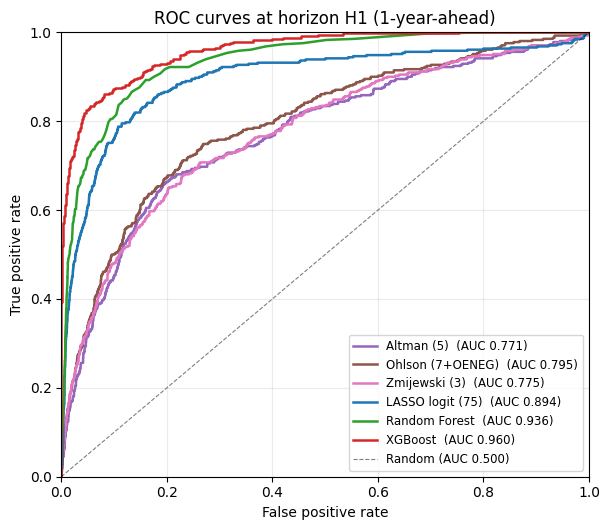

Saved fig_roc_h1.pdf


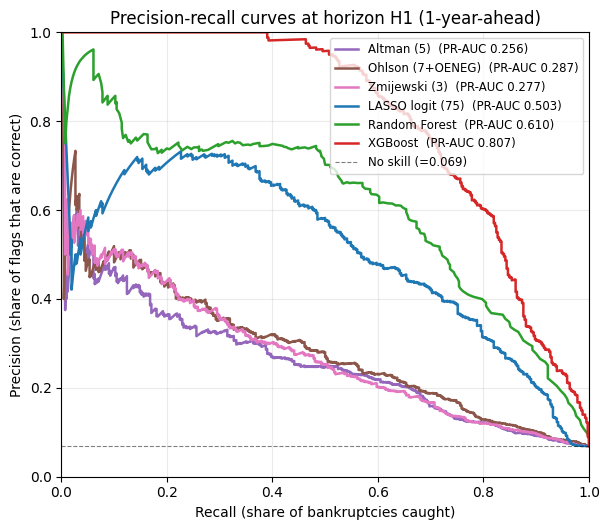

Saved fig_pr_h1.pdf


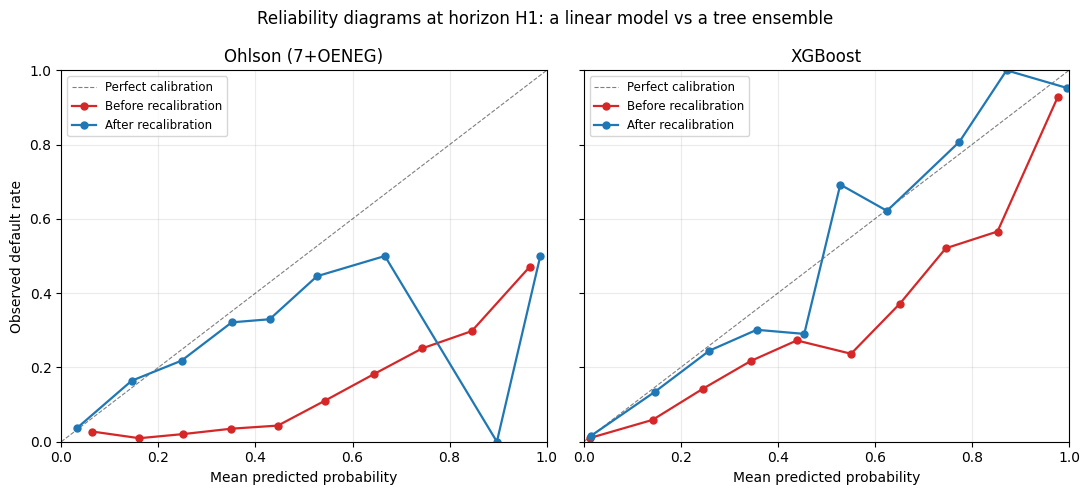

Saved fig_reliability_h1.pdf

Figures complete.


In [8]:
#
# This section turns the cross-validated predictions into the figures used in
# the paper. Every model's run_cv() output already stores its pooled
# out-of-fold (OOF) predicted probabilities -- one honest held-out prediction
# per firm -- so we can draw ROC curves, precision-recall curves, and
# reliability (calibration) diagrams directly from those, with no refitting.
#
# Produces three figures saved as PDF (vector, for LaTeX):
#   fig_roc_h1.pdf            ROC curves, all seven models
#   fig_pr_h1.pdf             Precision-recall curves, all seven models
#   fig_reliability_h1.pdf    Reliability diagrams, before vs after recalibration
#
# Requires the model runs from the preceding sections (all_results, and the
# recalibrated runs if RUN_RECALIBRATION was True). Dependencies: matplotlib.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

# Consistent colors/order across all figures.
PLOT_ORDER = ['Altman (5)', 'Ohlson (7+OENEG)', 'Zmijewski (3)',
              'LASSO logit (75)', 'Random Forest', 'XGBoost']
PLOT_COLORS = {
    'Altman (5)':       '#9467bd',
    'Ohlson (7+OENEG)': '#8c564b',
    'Zmijewski (3)':    '#e377c2',
    'LASSO logit (75)': '#1f77b4',
    'Random Forest':    '#2ca02c',
    'XGBoost':          '#d62728',
}

# Index the model results by label for easy lookup.
by_label = {r['label']: r for r in all_results}
y_true = horizons['H1']['y'].astype(int).values

# -----------------------------------------------------------------------------
# Figure 1: ROC curves.
# -----------------------------------------------------------------------------
# The ROC curve plots the true-positive rate against the false-positive rate
# as the decision threshold varies. A curve hugging the top-left corner is
# better; the diagonal is random guessing. The legend reports each model's AUC.
fig, ax = plt.subplots(figsize=(6.2, 5.4))
for lab in PLOT_ORDER:
    p = by_label[lab]['oof_prob']
    fpr, tpr, _ = roc_curve(y_true, p)
    auc = by_label[lab]['oof']['AUC']
    ax.plot(fpr, tpr, color=PLOT_COLORS[lab], lw=1.8,
            label=f"{lab}  (AUC {auc:.3f})")
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5, label='Random (AUC 0.500)')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curves at horizon H1 (1-year-ahead)')
ax.legend(loc='lower right', fontsize=8.5, frameon=True)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig('fig_roc_h1.pdf')
plt.show()
plt.close(fig)
print("Saved fig_roc_h1.pdf")

# -----------------------------------------------------------------------------
# Figure 2: Precision-recall curves.
# -----------------------------------------------------------------------------
# More informative than ROC under heavy class imbalance: it shows, for each
# recall level (share of true bankruptcies caught), the precision achieved
# (share of flagged firms that are truly bankrupt). The dashed line is the
# no-skill baseline at the base rate. The legend reports each model's PR-AUC.
base_rate = y_true.mean()
fig, ax = plt.subplots(figsize=(6.2, 5.4))
for lab in PLOT_ORDER:
    p = by_label[lab]['oof_prob']
    prec, rec, _ = precision_recall_curve(y_true, p)
    pr_auc = by_label[lab]['oof']['PR_AUC']
    ax.plot(rec, prec, color=PLOT_COLORS[lab], lw=1.8,
            label=f"{lab}  (PR-AUC {pr_auc:.3f})")
ax.axhline(base_rate, color='k', ls='--', lw=0.8, alpha=0.5,
           label=f'No skill (={base_rate:.3f})')
ax.set_xlabel('Recall (share of bankruptcies caught)')
ax.set_ylabel('Precision (share of flags that are correct)')
ax.set_title('Precision-recall curves at horizon H1 (1-year-ahead)')
ax.legend(loc='upper right', fontsize=8.5, frameon=True)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig('fig_pr_h1.pdf')
plt.show()
plt.close(fig)
print("Saved fig_pr_h1.pdf")

# -----------------------------------------------------------------------------
# Figure 3: Reliability diagrams (before vs after recalibration).
# -----------------------------------------------------------------------------
# A reliability diagram plots, for each probability bin, the observed default
# rate against the mean predicted probability. A perfectly calibrated model
# lies on the 45-degree line; points below the line mean the model is
# over-predicting risk. We show two representative models -- a class-weighted
# logit (Ohlson) and a tree ensemble (XGBoost) -- before and after isotonic
# recalibration, using the reliability_curve() helper defined earlier.
def _plot_reliability(ax, y, p, color, label):
    mp, orate, cnt = reliability_curve(y, p, n_bins=10)
    ok = ~np.isnan(mp)
    ax.plot(mp[ok], orate[ok], 'o-', color=color, lw=1.6, ms=5, label=label)

if 'RUN_RECALIBRATION' in dir() and RUN_RECALIBRATION:
    by_label_c = {r['label']: r for r in all_results_c}

    fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
    for ax, model in zip(axes, ['Ohlson (7+OENEG)', 'XGBoost']):
        ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5, label='Perfect calibration')
        _plot_reliability(ax, y_true, by_label[model]['oof_prob'],
                          '#d62728', 'Before recalibration')
        _plot_reliability(ax, y_true, by_label_c[model]['oof_prob'],
                          '#1f77b4', 'After recalibration')
        ax.set_title(f'{model}')
        ax.set_xlabel('Mean predicted probability')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.grid(alpha=0.25)
        ax.legend(loc='upper left', fontsize=8.5)
    axes[0].set_ylabel('Observed default rate')
    fig.suptitle('Reliability diagrams at horizon H1: a linear model vs a tree ensemble',
                 fontsize=12)
    fig.tight_layout()
    fig.savefig('fig_reliability_h1.pdf')
    plt.show()
    plt.close(fig)
    print("Saved fig_reliability_h1.pdf")
else:
    print("Skipped reliability figure (set RUN_RECALIBRATION = True to produce it).")

print("\nFigures complete.")

## 8. Calibration anatomy: the Brier score decomposition

Split the Brier score into calibration error (reliability), sorting power (resolution), and a fixed data term (uncertainty), before and after recalibration. Shows precisely why the tree ensembles calibrate and sort better, and what recalibration does and does not fix.

In [9]:
#
# The Brier score in the comparison table is a single number, but it bundles
# together two distinct things a model can do well or badly. Murphy's (1973)
# decomposition splits it into three interpretable parts:
#
#     Brier  =  Reliability  -  Resolution  +  Uncertainty
#
#   * RELIABILITY (lower is better): the average squared gap between a bin's
#     predicted probability and the actual default rate in that bin. This is
#     pure calibration error -- it is what isotonic recalibration fixes.
#
#   * RESOLUTION (higher is better): how far the bin default rates spread away
#     from the overall base rate. A model with high resolution sorts firms into
#     groups with genuinely different risk -- this is discrimination/sharpness.
#
#   * UNCERTAINTY: the base-rate variance p*(1-p). It depends only on the data,
#     not the model, so it is identical for every model at a given horizon and
#     sets the score that a constant "predict the base rate" model would get.
#
# Decomposing the Brier score shows WHY one model calibrates better than
# another: a high total Brier can come from poor calibration (high reliability
# term) or from weak sorting (low resolution), and the two call for different
# fixes. We report the decomposition for every model, before and after
# recalibration, and confirm the three parts add back to the raw Brier score.
#
# Requires the model runs (all_results, and all_results_c if recalibration was
# run). Dependencies: numpy, pandas.
# =============================================================================

import numpy as np
import pandas as pd


def brier_decomposition(y_true, y_prob, n_bins=10):
    """
    Murphy (1973) three-component decomposition of the Brier score.

    Bins predictions into n_bins equal-width probability bins and returns a
    dict with the reliability, resolution, and uncertainty terms, the
    recombined Brier (= rel - res + unc), and the directly-computed Brier for
    a cross-check. The two Brier numbers should match to within rounding.
    """
    y_true = np.asarray(y_true).astype(float)
    y_prob = np.asarray(y_prob, dtype=float)
    N = len(y_true)
    base = y_true.mean()

    edges = np.linspace(0.0, 1.0, n_bins + 1)
    # bin index in [0, n_bins-1]
    idx = np.clip(np.digitize(y_prob, edges[1:-1], right=False), 0, n_bins - 1)

    reliability = 0.0
    resolution = 0.0
    for b in range(n_bins):
        m = idx == b
        nb = int(m.sum())
        if nb == 0:
            continue
        conf_b = y_prob[m].mean()     # mean predicted probability in the bin
        obs_b = y_true[m].mean()      # observed default rate in the bin
        reliability += nb * (conf_b - obs_b) ** 2
        resolution += nb * (obs_b - base) ** 2
    reliability /= N
    resolution /= N
    uncertainty = base * (1.0 - base)

    brier_recombined = reliability - resolution + uncertainty
    brier_direct = np.mean((y_prob - y_true) ** 2)
    return {
        'reliability': reliability,
        'resolution': resolution,
        'uncertainty': uncertainty,
        'brier_recombined': brier_recombined,
        'brier_direct': brier_direct,
    }


# -----------------------------------------------------------------------------
# Apply to every model's pooled out-of-fold predictions (raw, no recalibration).
# -----------------------------------------------------------------------------
y_true = horizons['H1']['y'].astype(int).values
by_label = {r['label']: r for r in all_results}

ORDER = ['Altman (5)', 'Ohlson (7+OENEG)', 'Zmijewski (3)',
         'LASSO logit (75)', 'Random Forest', 'XGBoost']

print("=" * 86)
print("BRIER DECOMPOSITION — raw probabilities, H1   (Brier = Reliability - Resolution + Uncertainty)")
print("=" * 86)
rows = []
for lab in ORDER:
    d = brier_decomposition(y_true, by_label[lab]['oof_prob'])
    rows.append({
        'Model': lab,
        'Reliability': d['reliability'],     # lower better (calibration error)
        'Resolution': d['resolution'],       # higher better (sharpness)
        'Uncertainty': d['uncertainty'],     # constant across models
        'Brier': d['brier_recombined'],
        'check': d['brier_direct'],          # should match Brier
    })
dec_raw = pd.DataFrame(rows).set_index('Model')
print(dec_raw.round(4).to_string())
print("\n'check' is the directly-computed Brier; it matches the recombined Brier,")
print("confirming the decomposition. Uncertainty is identical for all models.")

# -----------------------------------------------------------------------------
# Same decomposition AFTER recalibration, if those runs are available.
# -----------------------------------------------------------------------------
if 'all_results_c' in dir():
    by_label_c = {r['label']: r for r in all_results_c}
    print("\n" + "=" * 86)
    print("BRIER DECOMPOSITION — after isotonic recalibration, H1")
    print("=" * 86)
    rows = []
    for lab in ORDER:
        if lab not in by_label_c:
            continue
        d = brier_decomposition(y_true, by_label_c[lab]['oof_prob'])
        rows.append({
            'Model': lab,
            'Reliability': d['reliability'],
            'Resolution': d['resolution'],
            'Uncertainty': d['uncertainty'],
            'Brier': d['brier_recombined'],
        })
    dec_recal = pd.DataFrame(rows).set_index('Model')
    print(dec_recal.round(4).to_string())

    # The key contrast: recalibration should shrink RELIABILITY (calibration
    # error) toward zero while leaving RESOLUTION (sorting power) almost intact.
    print("\n" + "=" * 86)
    print("WHAT RECALIBRATION CHANGES: reliability and resolution, before vs after")
    print("=" * 86)
    common = [l for l in ORDER if l in by_label_c]
    contrast = pd.DataFrame({
        'Reliab_before': dec_raw.loc[common, 'Reliability'],
        'Reliab_after':  dec_recal.loc[common, 'Reliability'],
        'Resol_before':  dec_raw.loc[common, 'Resolution'],
        'Resol_after':   dec_recal.loc[common, 'Resolution'],
    })
    print(contrast.round(4).to_string())
    print("\nReliability (calibration error) falls sharply; resolution (sorting")
    print("power) is essentially preserved. That is exactly what a good post-hoc")
    print("recalibration should do.")
else:
    print("\n(Recalibrated runs not in memory; set RUN_RECALIBRATION = True to")
    print(" produce the after-recalibration decomposition.)")

print("\nBrier decomposition complete.")

BRIER DECOMPOSITION — raw probabilities, H1   (Brier = Reliability - Resolution + Uncertainty)
                  Reliability  Resolution  Uncertainty   Brier   check
Model                                                                 
Altman (5)             0.1342      0.0071       0.0646  0.1917  0.1922
Ohlson (7+OENEG)       0.1191      0.0079       0.0646  0.1757  0.1757
Zmijewski (3)          0.1314      0.0076       0.0646  0.1883  0.1887
LASSO logit (75)       0.0597      0.0206       0.0646  0.1037  0.1041
Random Forest          0.0023      0.0261       0.0646  0.0408  0.0404
XGBoost                0.0035      0.0374       0.0646  0.0306  0.0302

'check' is the directly-computed Brier; it matches the recombined Brier,
confirming the decomposition. Uncertainty is identical for all models.

BRIER DECOMPOSITION — after isotonic recalibration, H1
                  Reliability  Resolution  Uncertainty   Brier
Model                                                         
Altman (5)

## 9. Performance across prediction horizons

Re-run all seven models on each of the five horizons (1 to 5 years ahead) and compare. Produces the two-panel horizon-degradation chart. Note: this section refits every model on every horizon, so it takes several minutes.

HORIZON DEGRADATION GRID

--- H1: n=5,910, bankruptcies=410 (6.9%) ---
  Altman (5)           AUC=0.772  PR-AUC=0.265  [0s]
  Ohlson (7+OENEG)     AUC=0.795  PR-AUC=0.297  [0s]
  Zmijewski (3)        AUC=0.776  PR-AUC=0.286  [0s]
  LASSO logit (75)     AUC=0.892  PR-AUC=0.500  [5s]
  Random Forest        AUC=0.937  PR-AUC=0.621  [18s]
  XGBoost              AUC=0.960  PR-AUC=0.810  [7s]

--- H2: n=9,792, bankruptcies=515 (5.3%) ---
  Altman (5)           AUC=0.700  PR-AUC=0.132  [0s]
  Ohlson (7+OENEG)     AUC=0.665  PR-AUC=0.110  [1s]
  Zmijewski (3)        AUC=0.698  PR-AUC=0.131  [0s]
  LASSO logit (75)     AUC=0.865  PR-AUC=0.337  [59s]
  Random Forest        AUC=0.915  PR-AUC=0.584  [31s]
  XGBoost              AUC=0.938  PR-AUC=0.724  [9s]

--- H3: n=10,503, bankruptcies=495 (4.7%) ---
  Altman (5)           AUC=0.679  PR-AUC=0.095  [0s]
  Ohlson (7+OENEG)     AUC=0.686  PR-AUC=0.095  [1s]
  Zmijewski (3)        AUC=0.693  PR-AUC=0.098  [0s]
  LASSO logit (75)     AUC=0.866  PR-A

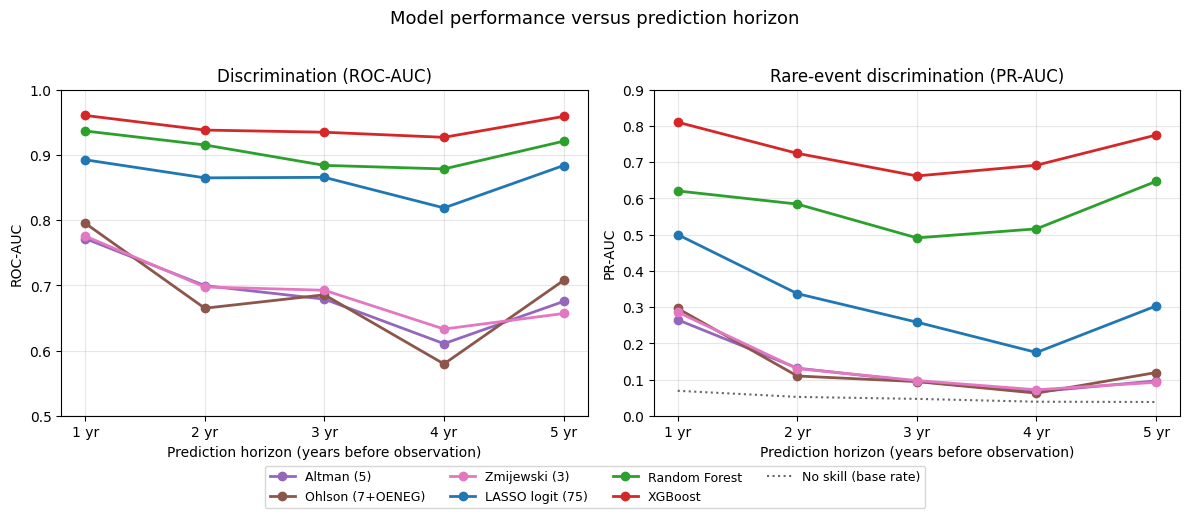


Saved fig_horizon.pdf


In [10]:
#
# So far every result has been at horizon H1 (financial statements one year
# before the bankruptcy observation). The dataset also provides H2 through H5,
# where the predictors are two to five years before the event. Longer horizons
# are inherently harder: by the time a firm is five years from failing, its
# financials look much more like a healthy firm's, so all models should lose
# discriminatory power. The question is how quickly each model degrades and
# whether the gap between the families changes.
#
# We re-run every model on every horizon under the same protocol used at H1,
# then plot AUC and PR-AUC as a function of horizon. Saves a two-panel figure
# (fig_horizon.pdf) for the paper.
#
# Requires the harness (run_cv) and feature sets from earlier sections.
# Dependencies: numpy, pandas, scikit-learn, xgboost, matplotlib.
# =============================================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


def _logit():
    """Plain class-weighted logit for the econometric baselines."""
    return LogisticRegression(class_weight='balanced', max_iter=5000, solver='lbfgs')


def _build_specs(spw):
    """Return the seven model specifications. spw = scale_pos_weight (neg/pos)."""
    return [
        ('Altman (5)',       _logit(), ALTMAN_5,    (),        True),
        ('Ohlson (7+OENEG)', _logit(), OHLSON_7,    ['OENEG'], True),
        ('Zmijewski (3)',    _logit(), ZMIJEWSKI_3, (),        True),
        ('LASSO logit (75)', LogisticRegression(
            penalty='l1', solver='liblinear', C=0.1,
            class_weight='balanced', max_iter=200, tol=1e-2, random_state=42),
         FEATURES, MISS_INDS, True),
        ('Ridge logit (75)', LogisticRegression(
            penalty='l2', solver='lbfgs', C=1.0,
            class_weight='balanced', max_iter=2000, random_state=42),
         FEATURES, MISS_INDS, True),
        ('Random Forest',    RandomForestClassifier(
            n_estimators=200, max_features='sqrt', class_weight='balanced',
            n_jobs=2, random_state=42),
         FEATURES, MISS_INDS, False),
        ('XGBoost',          XGBClassifier(
            n_estimators=400, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
            reg_lambda=1.0, scale_pos_weight=spw,
            eval_metric='aucpr', tree_method='hist',
            n_jobs=2, random_state=42),
         FEATURES, MISS_INDS, False),
    ]


# -----------------------------------------------------------------------------
# Run every model on every horizon.
# -----------------------------------------------------------------------------
# Note: the LASSO uses loose convergence (max_iter=200, tol=1e-2) here because
# liblinear with class_weight='balanced' converges slowly on the larger H2-H4
# samples. With sufficient memory and time (e.g. on Colab) max_iter can be
# raised; results change only marginally.
print("=" * 78)
print("HORIZON DEGRADATION GRID")
print("=" * 78)
t_total = time.time()
rows = []
for h in ['H1', 'H2', 'H3', 'H4', 'H5']:
    Xh = horizons[h]
    Xh['OENEG'] = (Xh['TL_TA'] > 1).astype('int8')
    y = Xh['y'].astype(int).values
    neg, pos = int((y == 0).sum()), int((y == 1).sum())
    spw = neg / pos
    print(f"\n--- {h}: n={len(Xh):,}, bankruptcies={pos} ({pos/len(Xh)*100:.1f}%) ---")
    for lab, clf, nc, pc, sc in _build_specs(spw):
        t = time.time()
        r = run_cv(clf, X=Xh, y=Xh['y'], num_cols=nc, passthrough_cols=pc,
                   scale=sc, label=lab, verbose=False)
        s = r['summary']['mean']
        rows.append({
            'horizon': h, 'model': lab,
            'AUC':       float(s['AUC']),
            'PR_AUC':    float(s['PR_AUC']),
            'Brier':     float(s['Brier']),
            'ECE':       float(s['ECE']),
            'recall':    float(s['recall']),
            'precision': float(s['precision']),
            'cost_norm': float(s['cost_norm']),
        })
        print(f"  {lab:20s} AUC={s['AUC']:.3f}  PR-AUC={s['PR_AUC']:.3f}  "
              f"[{time.time()-t:.0f}s]")
print(f"\nTotal time: {time.time()-t_total:.0f}s")

horizon_df = pd.DataFrame(rows)
horizon_df.to_csv('horizon_results.csv', index=False)

print("\n" + "=" * 78)
print("AUC by horizon")
print("=" * 78)
print(horizon_df.pivot(index='model', columns='horizon', values='AUC')
                 .round(3).to_string())

print("\n" + "=" * 78)
print("PR-AUC by horizon")
print("=" * 78)
print(horizon_df.pivot(index='model', columns='horizon', values='PR_AUC')
                 .round(3).to_string())

# -----------------------------------------------------------------------------
# Two-panel figure: AUC and PR-AUC as a function of prediction horizon.
# -----------------------------------------------------------------------------
PLOT_ORDER = ['Altman (5)', 'Ohlson (7+OENEG)', 'Zmijewski (3)',
              'LASSO logit (75)', 'Random Forest', 'XGBoost']
PLOT_COLORS = {
    'Altman (5)':       '#9467bd',
    'Ohlson (7+OENEG)': '#8c564b',
    'Zmijewski (3)':    '#e377c2',
    'LASSO logit (75)': '#1f77b4',
    'Random Forest':    '#2ca02c',
    'XGBoost':          '#d62728',
}
HORIZONS = ['H1', 'H2', 'H3', 'H4', 'H5']
H_LABELS = ['1 yr', '2 yr', '3 yr', '4 yr', '5 yr']

fig, (ax_auc, ax_pr) = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

for lab in PLOT_ORDER:
    sub = horizon_df[horizon_df['model'] == lab].set_index('horizon').loc[HORIZONS]
    ax_auc.plot(HORIZONS, sub['AUC'].values, marker='o', lw=2,
                color=PLOT_COLORS[lab], label=lab)
    ax_pr.plot(HORIZONS, sub['PR_AUC'].values, marker='o', lw=2,
               color=PLOT_COLORS[lab], label=lab)

# Base-rate reference on the PR panel (PR-AUC's no-skill line varies with
# horizon because the bankruptcy rate does).
base_rates = [horizons[h]['y'].mean() for h in HORIZONS]
ax_pr.plot(HORIZONS, base_rates, ':', color='black', alpha=0.6,
           label=f'No skill (base rate)')

ax_auc.set_title('Discrimination (ROC-AUC)')
ax_auc.set_ylabel('ROC-AUC')
ax_auc.set_xticks(range(len(HORIZONS)))
ax_auc.set_xticklabels(H_LABELS)
ax_auc.set_ylim(0.5, 1.0)
ax_auc.grid(alpha=0.3)
ax_auc.axhline(0.5, color='black', lw=0.8, alpha=0.4)

ax_pr.set_title('Rare-event discrimination (PR-AUC)')
ax_pr.set_ylabel('PR-AUC')
ax_pr.set_xticks(range(len(HORIZONS)))
ax_pr.set_xticklabels(H_LABELS)
ax_pr.set_ylim(0, 0.9)
ax_pr.grid(alpha=0.3)

fig.suptitle('Model performance versus prediction horizon', fontsize=13)
ax_auc.set_xlabel('Prediction horizon (years before observation)')
ax_pr.set_xlabel('Prediction horizon (years before observation)')

# One shared legend below both panels.
handles, labels = ax_pr.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.03), fontsize=9, frameon=True)
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
fig.savefig('fig_horizon.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)
print("\nSaved fig_horizon.pdf")

## 10. Pooled cross-horizon model: horizon dummies, slopes, and macro

The previous section ran a separate model on each horizon file. Here we pool all five files into one sample (43,405 firm-horizon observations) and use the horizon structure directly. This is the part of a panel design the data allow: we cannot build firm-level fixed effects (firms are anonymized with no identifier and no calendar date), but we can add horizon dummies, horizon-level macro variables, and interactions between the ratios and the horizon.

We answer three questions:

1. **Horizon intercept dummies.** How much of the cross-horizon difference is just a shift in the baseline default rate? A dummy for each horizon (H1 as base) captures this, playing the role of period effects in a hazard model.
2. **Horizon-level macro variables.** Each horizon file sits at a different average point in the macro cycle, so we can attach window-averaged Polish macro values (GDP growth, CPI, unemployment, NBP rate). Because each horizon has one set of macro values, these are collinear with the horizon dummies, so we expect them to add little once the dummies are in. We report that honestly.
3. **Slope interactions.** Do the ratios mean the same thing at every horizon? Interacting each ratio with the horizon dummies tests this. A likelihood-ratio test checks joint significance, and single-ratio models show the direction of each effect across horizons.

The headline finding is that the predictive content of the standard ratios is concentrated close to the event and fades as the horizon lengthens.

In [ ]:
# =============================================================================
# Pooled cross-horizon econometric analysis.
# Requires the `horizons` dict and OHLSON_7 / FEATURES lists from the earlier
# data-loading section.
# =============================================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

# --- Polish macro series 2000-2013 (sources: World Bank, GUS, Eurostat, NBP) ---
macro = pd.DataFrame({
    "year":  list(range(2000, 2014)),
    "gdp":   [4.66, 1.23, 1.90, 3.52, 5.09, 3.26, 6.20, 6.76, 4.38, 2.62, 3.17, 5.26, 1.51, 0.68],
    "cpi":   [10.1, 5.5, 1.9, 0.7, 3.5, 2.2, 1.2, 2.5, 4.3, 3.8, 2.6, 4.2, 3.7, 1.1],
    "unemp": [15.1, 17.5, 20.0, 20.0, 19.0, 17.6, 14.8, 11.2, 9.5, 12.1, 12.4, 12.5, 13.4, 13.4],
    "nbp":   [19.0, 11.5, 6.75, 5.25, 6.5, 4.5, 4.0, 5.0, 5.0, 3.5, 3.5, 4.5, 4.25, 2.5],
}).set_index("year")

# Each horizon file is observed a different distance before the outcome, so it
# maps to a different representative observation year. We anchor on the
# operating-firm window (2007-2013) and step back by horizon distance, then take
# a 3-year average around the representative year as a smoothed macro feature.
horizon_year = {"H1": 2012, "H2": 2011, "H3": 2010, "H4": 2009, "H5": 2008}

def macro_avg(yr):
    yrs = [y for y in (yr - 1, yr, yr + 1) if y in macro.index]
    return macro.loc[yrs].mean()

hmacro = {h: macro_avg(y) for h, y in horizon_year.items()}

# --- Build the pooled sample -------------------------------------------------
pieces = []
for h in ["H1", "H2", "H3", "H4", "H5"]:
    df = horizons[h].copy()
    df["horizon"] = h
    for k in ["gdp", "cpi", "unemp", "nbp"]:
        df[k] = hmacro[h][k]
    pieces.append(df)
pool = pd.concat(pieces, ignore_index=True)
y = pool["y"].astype(int).values

print(f"Pooled sample: n={len(pool):,}, bankrupt={int(pool['y'].sum()):,} "
      f"({pool['y'].mean()*100:.2f}%)")
print("\nDefault rate by horizon:")
print(pool.groupby("horizon")["y"].mean().round(4).to_string())

# Ohlson-style ratios available in every file (standardized for comparability).
ohlson_cols = [c for c in OHLSON_7 if c in pool.columns]

def standardize(cols, src=pool):
    X = src[cols].copy()
    for c in cols:
        X[c] = X[c].fillna(X[c].median())
        X[c] = X[c].clip(X[c].quantile(0.01), X[c].quantile(0.99))
        s = X[c].std()
        X[c] = (X[c] - X[c].mean()) / (s if s > 0 else 1.0)
    return X.reset_index(drop=True)

X0 = standardize(ohlson_cols)
Hd = pd.get_dummies(pool["horizon"], prefix="H", drop_first=True).astype(float).reset_index(drop=True)

def cv_auc_pr(Xmat):
    """5-fold stratified CV AUC and PR-AUC for a statsmodels logit."""
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    Xv = sm.add_constant(Xmat, has_constant="add").astype(float).values
    aucs, prs = [], []
    for tr, va in skf.split(Xmat, y):
        m = sm.Logit(y[tr], Xv[tr]).fit(disp=0, maxiter=300)
        p = m.predict(Xv[va])
        aucs.append(roc_auc_score(y[va], p))
        prs.append(average_precision_score(y[va], p))
    return np.mean(aucs), np.mean(prs)

# --- (1) Horizon intercept dummies ------------------------------------------
XB = pd.concat([X0, Hd], axis=1)
mB = sm.Logit(y, sm.add_constant(XB, has_constant="add").astype(float).values).fit(disp=0, maxiter=300)
names_B = ["const"] + list(XB.columns)
params_B = dict(zip(names_B, mB.params))
pvals_B = dict(zip(names_B, mB.pvalues))

print("\n" + "=" * 70)
print("(1) HORIZON INTERCEPT DUMMIES (H1 = base)")
print("=" * 70)
for h in ["H_H2", "H_H3", "H_H4", "H_H5"]:
    print(f"  {h[2:]}: coef={params_B[h]:+.3f}  p={pvals_B[h]:.2e}  "
          f"odds ratio={np.exp(params_B[h]):.3f}")

# --- (2) Horizon-level macro variables (collinear with dummies) -------------
Mc = standardize(["gdp", "cpi", "unemp", "nbp"])
XC = pd.concat([X0, Mc], axis=1)
auc_dum, pr_dum = cv_auc_pr(XB)
auc_macro, pr_macro = cv_auc_pr(XC)
print("\n" + "=" * 70)
print("(2) MACRO VARIABLES VS HORIZON DUMMIES")
print("=" * 70)
print(f"  ratios + horizon dummies: AUC={auc_dum:.4f}  PR-AUC={pr_dum:.4f}")
print(f"  ratios + macro variables: AUC={auc_macro:.4f}  PR-AUC={pr_macro:.4f}")
print("  (Each horizon has one set of macro values, so macro and the horizon")
print("   dummies describe the same variation; the dummies are more flexible.)")

# --- (3) Slope interactions: do ratio effects change with horizon? ----------
key = ["TL_TA", "net_profit_TA", "WC_TA"]
key = [c for c in key if c in X0.columns]
inter = {f"{k}_x_{hc}": X0[k].values * Hd[hc].values for k in key for hc in Hd.columns}
Xint = pd.concat([X0, Hd, pd.DataFrame(inter)], axis=1)
mD = sm.Logit(y, sm.add_constant(Xint, has_constant="add").astype(float).values).fit(disp=0, maxiter=300)

LR = 2 * (mD.llf - mB.llf)
df_diff = Xint.shape[1] - XB.shape[1]
p_LR = stats.chi2.sf(LR, df_diff)
print("\n" + "=" * 70)
print("(3) SLOPE INTERACTIONS (ratio x horizon)")
print("=" * 70)
print(f"  LR test for joint significance: chi2={LR:.1f}, df={df_diff}, p={p_LR:.2e}")

# Single-ratio models so each coefficient keeps its natural economic sign.
ratio_labels = {"TL_TA": "Leverage (TL/TA)",
                "net_profit_TA": "Profitability (NI/TA)",
                "WC_TA": "Working capital (WC/TA)",
                "CA_STL": "Liquidity (CA/STL)"}
single = {}
for c in ratio_labels:
    if c not in pool.columns:
        continue
    x = standardize([c])[c]
    inter_c = {f"x_{hc}": x.values * Hd[hc].values for hc in Hd.columns}
    Xc = pd.concat([pd.Series(x, name="ratio"), Hd, pd.DataFrame(inter_c)], axis=1)
    m = sm.Logit(y, sm.add_constant(Xc, has_constant="add").astype(float).values).fit(disp=0, maxiter=300)
    nm = ["const", "ratio"] + list(Hd.columns) + [f"x_{hc}" for hc in Hd.columns]
    pp = dict(zip(nm, m.params))
    single[c] = [pp["ratio"]] + [pp["ratio"] + pp[f"x_H_{h}"] for h in ["H2", "H3", "H4", "H5"]]

print("\nSingle-ratio coefficients by horizon (H1 -> H5):")
for c, coefs in single.items():
    print(f"  {ratio_labels[c]:24s} " + "  ".join(f"{v:+.3f}" for v in coefs))

# --- Figure: how each ratio's effect changes with the horizon ---------------
H = ["H1", "H2", "H3", "H4", "H5"]
xpos = np.arange(len(H))
style = {"TL_TA": ("#d62728", "o"), "net_profit_TA": ("#1f77b4", "s"),
         "WC_TA": ("#2ca02c", "^"), "CA_STL": ("#ff7f0e", "D")}
fig, ax = plt.subplots(figsize=(8.5, 5))
for c, coefs in single.items():
    col, mk = style.get(c, ("#333333", "o"))
    ax.plot(xpos, coefs, marker=mk, color=col, lw=2, markersize=8, label=ratio_labels[c])
ax.axhline(0, color="black", lw=0.8, alpha=0.5)
ax.set_xticks(xpos)
ax.set_xticklabels([f"{h}\n({i+1} yr)" for i, h in enumerate(H)])
ax.set_xlabel("Prediction horizon (years before outcome)")
ax.set_ylabel("Standardized logit coefficient")
ax.set_title("How the effect of each financial ratio changes with prediction horizon")
ax.legend(fontsize=9, loc="center right")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("fig_slope_horizon.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)
print("\nSaved fig_slope_horizon.pdf")
print("\nPooled cross-horizon analysis complete.")


## 11. Opening the black box: SHAP interpretation of XGBoost

Use SHAP values to explain what drives the XGBoost predictions: a global importance ranking and a per-firm beeswarm plot showing the direction of each feature's effect. Confirms the model relies on economically sensible variables.

SHAP INTERPRETATION OF XGBOOST (fitted on full H1 sample)

Top 15 features by mean |SHAP| (global importance):
                   mean_abs_SHAP              type
OpEx_TL                   0.5763   financial ratio
profit_sales              0.5506   financial ratio
miss_OP_finexp            0.5360  missingness flag
sales_growth              0.5003   financial ratio
CA_inv_STL                0.4281   financial ratio
eq_minus_share_TA         0.3486   financial ratio
miss_sales_growth         0.3366  missingness flag
totcost_totsales          0.3289   financial ratio
profit_sales_TA           0.3263   financial ratio
OP_finexp                 0.2559   financial ratio
GP3yr_TA                  0.2424   financial ratio
NP_DA_TL                  0.2362   financial ratio
EBITDA_TA                 0.2299   financial ratio
OP_sales                  0.2003   financial ratio
const_cap_TA              0.1896   financial ratio

Of the top 15 features, 2 are missingness flags.


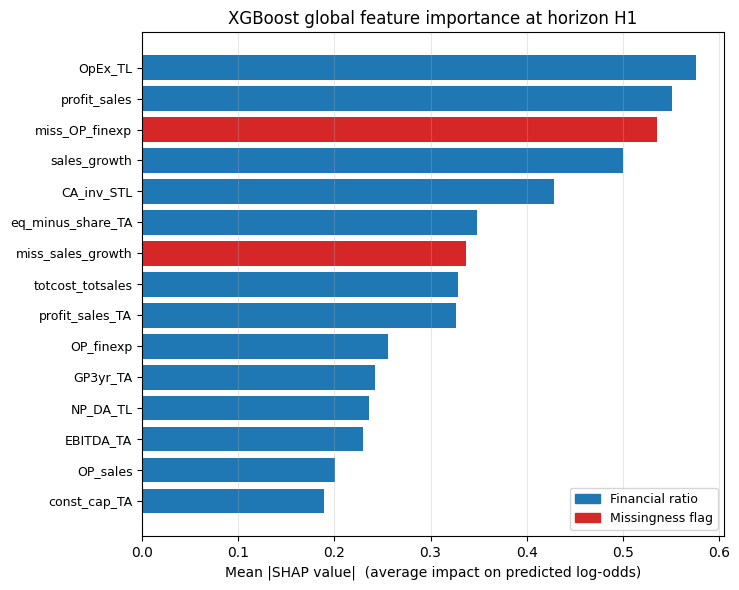

Saved fig_shap_bar.pdf


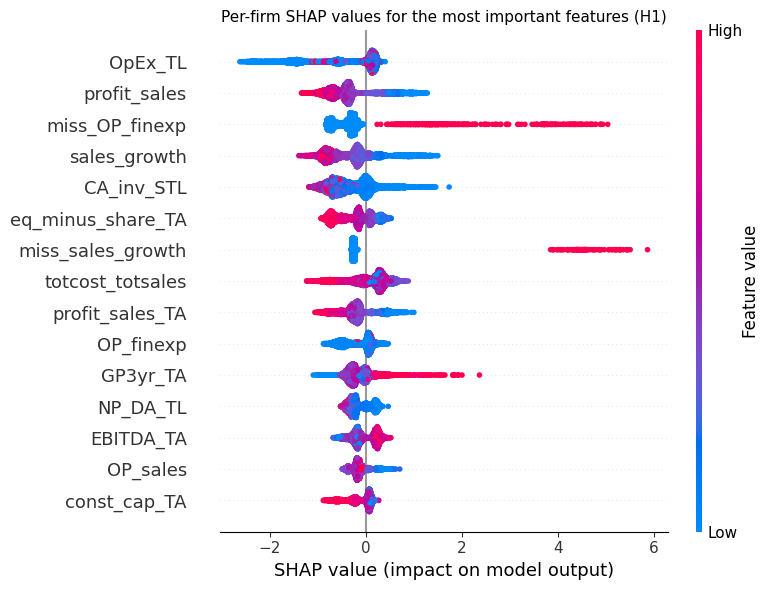

Saved fig_shap_beeswarm.pdf

SHAP interpretation complete.


In [11]:
#
# XGBoost is accurate but, unlike the logit, it does not hand us a simple table
# of coefficients to read. SHAP (SHapley Additive exPlanations) fills that gap.
# For every firm and every feature, SHAP assigns a value measuring how much
# that feature pushed the firm's predicted log-odds of bankruptcy up or down,
# relative to the average prediction. The values have a firm grounding in
# cooperative game theory and, crucially, add up exactly to the model's
# prediction for each firm.
#
# We use SHAP two ways:
#   1. GLOBAL importance -- average absolute SHAP value per feature, to rank
#      which variables matter most to XGBoost overall. We compare this ranking
#      to the LASSO's variable selection and the logit coefficients.
#   2. DIRECTION and SHAPE -- a beeswarm summary plot showing, for the most
#      important features, whether high values push risk up or down and how
#      the effect varies across firms.
#
# Produces two figures:
#   fig_shap_bar.pdf       global feature importance (mean |SHAP|)
#   fig_shap_beeswarm.pdf  per-firm SHAP values for the top features
#
# Requires the data and feature lists from earlier sections.
# Dependencies: shap, xgboost, scikit-learn, matplotlib.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer

ALL_FEATURES = FEATURES + MISS_INDS

# -----------------------------------------------------------------------------
# Fit XGBoost on the full H1 sample (SHAP explains one fitted model, not a CV
# loop). We use the same settings as the cross-validated XGBoost elsewhere.
# Missing ratios are median-imputed; the 11 missingness indicators are kept.
# -----------------------------------------------------------------------------
print("=" * 78)
print("SHAP INTERPRETATION OF XGBOOST (fitted on full H1 sample)")
print("=" * 78)

Xh1 = horizons['H1']
y_h1 = Xh1['y'].astype(int).values
neg, pos = int((y_h1 == 0).sum()), int((y_h1 == 1).sum())
spw = neg / pos

# Median-impute ratios; keep readable column names for the SHAP plots.
imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(
    imputer.fit_transform(Xh1[ALL_FEATURES]),
    columns=ALL_FEATURES,
)

xgb_shap = XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_lambda=1.0, scale_pos_weight=spw,
    eval_metric='aucpr', tree_method='hist',
    n_jobs=2, random_state=42,
)
xgb_shap.fit(X_imp, y_h1)

# -----------------------------------------------------------------------------
# Compute SHAP values with the fast exact TreeExplainer.
# -----------------------------------------------------------------------------
explainer = shap.TreeExplainer(xgb_shap)
shap_values = explainer.shap_values(X_imp)   # shape: (n_firms, n_features)

# -----------------------------------------------------------------------------
# 1. Global importance: mean absolute SHAP value per feature.
# -----------------------------------------------------------------------------
mean_abs = np.abs(shap_values).mean(axis=0)
importance = (pd.Series(mean_abs, index=ALL_FEATURES)
                .sort_values(ascending=False))

print("\nTop 15 features by mean |SHAP| (global importance):")
imp_table = pd.DataFrame({
    'mean_abs_SHAP': importance.head(15),
    'type': ['missingness flag' if f.startswith('miss_') else 'financial ratio'
             for f in importance.head(15).index],
})
print(imp_table.round(4).to_string())

n_flags_top = sum(f.startswith('miss_') for f in importance.head(15).index)
print(f"\nOf the top 15 features, {n_flags_top} are missingness flags.")

# -----------------------------------------------------------------------------
# Figure 1: global importance bar chart (top 15).
# -----------------------------------------------------------------------------
top15 = importance.head(15)[::-1]   # reverse so largest is on top
colors = ['#d62728' if f.startswith('miss_') else '#1f77b4' for f in top15.index]

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.barh(range(len(top15)), top15.values, color=colors)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15.index, fontsize=9)
ax.set_xlabel('Mean |SHAP value|  (average impact on predicted log-odds)')
ax.set_title('XGBoost global feature importance at horizon H1')
# Manual legend for the two colors.
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#1f77b4', label='Financial ratio'),
                   Patch(color='#d62728', label='Missingness flag')],
          loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig('fig_shap_bar.pdf')
plt.show()
plt.close(fig)
print("Saved fig_shap_bar.pdf")

# -----------------------------------------------------------------------------
# Figure 2: beeswarm summary plot (top features, direction and spread).
# -----------------------------------------------------------------------------
# Each dot is one firm; horizontal position is that firm's SHAP value for the
# feature; color is the feature's value (red = high, blue = low). This shows
# not just which features matter, but which direction high values push risk.
plt.figure()
shap.summary_plot(shap_values, X_imp, max_display=15, show=False,
                  plot_size=(8, 6))
plt.title('Per-firm SHAP values for the most important features (H1)',
          fontsize=11)
plt.tight_layout()
plt.savefig('fig_shap_beeswarm.pdf', bbox_inches='tight')
plt.show()
plt.close()
print("Saved fig_shap_beeswarm.pdf")

print("\nSHAP interpretation complete.")

## 12. Robustness checks

Stress-test the main modeling choices and round out the comparison:

- **R1, complete-case analysis** — does median imputation drive the results?
- **R2, SMOTE versus class weighting** — is the imbalance handling hurting us?
- **R3, feature-breadth decomposition** — how much of the ML advantage comes from more variables versus nonlinear modeling? Now includes Ridge logit alongside the plain logit, LASSO, and the tree ensembles.
- **R4, PCA logit** — the strongest linear competitor on the full feature set, with multicollinearity removed by principal components. Tests directly whether the ML gap is about feature correlation or about nonlinearity.
- **R5, literature benchmark** — our results against the published results of Zięba et al. (2016) and Smiti and Soui (2020) on this same dataset, to confirm our pipeline reaches the published ceiling.

R1 -- COMPLETE-CASE ANALYSIS (H1)
Complete-case sample: n=3,031 (of 5,910), bankruptcies=102 (3.37%)

Complete-case results:
                            AUC  PR_AUC   Brier  recall  precision
Ohlson (complete-case)   0.8660  0.2445  0.1533  0.4005     0.3321
XGBoost (complete-case)  0.8971  0.5037  0.0255  0.5110     0.5978

For comparison, full-sample H1: Ohlson AUC=0.795/PR=0.297, XGBoost AUC=0.960/PR=0.810.
The ML edge shrinks on complete cases because the informative-missing
firms (which the trees exploit) are exactly the ones excluded here.

R2 -- SMOTE vs CLASS WEIGHTING (XGBoost, H1)
XGBoost + SMOTE:           AUC=0.937  PR-AUC=0.724  Brier=0.0435
XGBoost + class weighting: AUC=0.960  PR-AUC=0.810  Brier=0.030  (from main results)

SMOTE gives slightly lower discrimination and a worse (higher) Brier
score. Class weighting is the better choice here, and it avoids
fabricating synthetic firms with impossible financial-ratio combinations.

R3 -- FEATURE BREADTH VS ALGORITHMIC POWER 

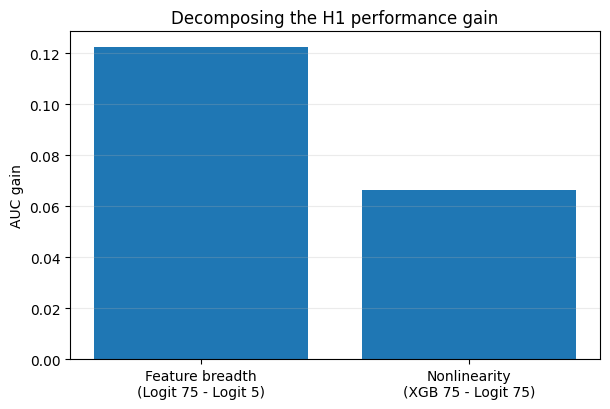

Saved fig_feature_decomposition.pdf

Robustness checks complete.


In [12]:
#
# The main results rest on three modeling choices: median imputation of missing
# ratios, class weighting (rather than resampling) to handle imbalance, and the
# use of all 75 features. This section stress-tests each choice with a targeted
# check, all at horizon H1.
#
#   R1  COMPLETE-CASE: re-run on only the rows with no missing values, to see
#       whether the imputation (and the missingness flags) drive the results.
#
#   R2  SMOTE: replace class weighting with SMOTE oversampling for XGBoost, to
#       check that our imbalance choice is not hurting us -- and to show what
#       resampling does to calibration.
#
#   R3  FEATURE BREADTH: run transferable model classes on four feature sets
#       (Altman-5, Ohlson-7, top-15 SHAP, all 75), so the ML advantage can be
#       decomposed into feature breadth versus nonlinear modeling.
#
# Requires the data, feature lists, and run_cv harness from earlier sections.
# Dependencies: scikit-learn, xgboost, imbalanced-learn.
# =============================================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             brier_score_loss)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

Xh1 = horizons['H1']
Xh1['OENEG'] = (Xh1['TL_TA'] > 1).astype('int8')
y_full = Xh1['y'].astype(int).values
neg_f, pos_f = int((y_full == 0).sum()), int((y_full == 1).sum())
spw_full = neg_f / pos_f


def _xgb(spw):
    return XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        reg_lambda=1.0, scale_pos_weight=spw,
        eval_metric='aucpr', tree_method='hist',
        n_jobs=2, random_state=42)


# =============================================================================
# R1 -- COMPLETE-CASE ANALYSIS
# =============================================================================
# We drop every row that has any missing ratio and re-run two representative
# models (Ohlson and XGBoost). If the headline results were an artefact of
# imputation, they should change a lot here. Note that the complete-case sample
# is not a random subset: it excludes the distressed firms whose missingness
# was itself a signal, so the bankruptcy rate falls and we expect the ML edge
# to shrink.
print("=" * 78)
print("R1 -- COMPLETE-CASE ANALYSIS (H1)")
print("=" * 78)

complete = ~Xh1[FEATURES].isna().any(axis=1)
Xcc = Xh1[complete].reset_index(drop=True)
ycc = Xcc['y'].astype(int).values
neg_c, pos_c = int((ycc == 0).sum()), int((ycc == 1).sum())
print(f"Complete-case sample: n={len(Xcc):,} (of {len(Xh1):,}), "
      f"bankruptcies={pos_c} ({ycc.mean()*100:.2f}%)")

r1 = []
r1.append(run_cv(LogisticRegression(class_weight='balanced', max_iter=5000,
                                    solver='lbfgs'),
                 X=Xcc, y=Xcc['y'], num_cols=OHLSON_7, passthrough_cols=['OENEG'],
                 scale=True, label='Ohlson (complete-case)', verbose=False))
r1.append(run_cv(_xgb(neg_c / pos_c),
                 X=Xcc, y=Xcc['y'], num_cols=FEATURES, passthrough_cols=MISS_INDS,
                 scale=False, label='XGBoost (complete-case)', verbose=False))

r1_tbl = compare_models(r1)[['AUC', 'PR_AUC', 'Brier', 'recall', 'precision']]
print("\nComplete-case results:")
print(r1_tbl.round(4).to_string())
print("\nFor comparison, full-sample H1: Ohlson AUC=0.795/PR=0.297, "
      "XGBoost AUC=0.960/PR=0.810.")
print("The ML edge shrinks on complete cases because the informative-missing")
print("firms (which the trees exploit) are exactly the ones excluded here.")


# =============================================================================
# R2 -- SMOTE INSTEAD OF CLASS WEIGHTING
# =============================================================================
# SMOTE creates synthetic minority-class examples to balance the training data.
# We apply it inside each fold (never touching the validation fold) and train
# XGBoost WITHOUT scale_pos_weight, then compare to our class-weighted XGBoost.
# The point is twofold: confirm class weighting is not costing us discrimination,
# and show that resampling tends to distort calibration.
print("\n" + "=" * 78)
print("R2 -- SMOTE vs CLASS WEIGHTING (XGBoost, H1)")
print("=" * 78)

X_all = Xh1[FEATURES + MISS_INDS]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs, prs, briers = [], [], []
for tr, va in skf.split(X_all, y_full):
    Xt, Xv = X_all.iloc[tr].copy(), X_all.iloc[va].copy()
    yt, yv = y_full[tr], y_full[va]
    med = Xt[FEATURES].median()
    for c in FEATURES:
        Xt[c] = Xt[c].fillna(med[c]); Xv[c] = Xv[c].fillna(med[c])
    # SMOTE on the training fold only.
    Xr, yr = SMOTE(random_state=42).fit_resample(Xt, yt)
    m = _xgb(spw=1)          # no class weight; SMOTE already balanced the data
    m.set_params(scale_pos_weight=1)
    m.fit(Xr, yr)
    p = m.predict_proba(Xv)[:, 1]
    aucs.append(roc_auc_score(yv, p))
    prs.append(average_precision_score(yv, p))
    briers.append(brier_score_loss(yv, p))

print(f"XGBoost + SMOTE:           AUC={np.mean(aucs):.3f}  "
      f"PR-AUC={np.mean(prs):.3f}  Brier={np.mean(briers):.4f}")
print(f"XGBoost + class weighting: AUC=0.960  PR-AUC=0.810  Brier=0.030  (from main results)")
print("\nSMOTE gives slightly lower discrimination and a worse (higher) Brier")
print("score. Class weighting is the better choice here, and it avoids")
print("fabricating synthetic firms with impossible financial-ratio combinations.")


# =============================================================================
# R3 -- FEATURE BREADTH VS ALGORITHMIC POWER
# =============================================================================
# The original robustness check only asked whether XGBoost needs all 75
# features. That was useful but too narrow: it mixed up the feature-set effect
# with the algorithm effect. Here we run the transferable model classes on four
# feature sets and explicitly separate the two channels.
#
# One methodological correction is important. Altman, Ohlson, and Zmijewski are
# not portable algorithms once the variables are changed; they are named
# specifications. Calling a 75-feature model "Altman" would be misleading.
# Therefore, for the decomposition grid we use a generic class-weighted logit as
# the linear econometric benchmark, then compare it with LASSO, random forest,
# and XGBoost. The original seven-model table above remains unchanged.
print("\n" + "=" * 78)
print("R3 -- FEATURE BREADTH VS ALGORITHMIC POWER (H1)")
print("=" * 78)

top15 = ['OpEx_TL', 'profit_sales', 'miss_OP_finexp', 'sales_growth',
         'CA_inv_STL', 'eq_minus_share_TA', 'miss_sales_growth',
         'totcost_totsales', 'profit_sales_TA', 'OP_finexp', 'GP3yr_TA',
         'NP_DA_TL', 'EBITDA_TA', 'OP_sales', 'const_cap_TA']
top15_num = [f for f in top15 if not f.startswith('miss_')]
top15_miss = [f for f in top15 if f.startswith('miss_')]

feature_sets = [
    ('Altman 5',        ALTMAN_5,   ()),
    ('Ohlson 7',        OHLSON_7,   ()),
    ('Top 15 (SHAP)',   top15_num,  top15_miss),
    ('All 75',          FEATURES,   MISS_INDS),
]


def _plain_logit():
    return LogisticRegression(class_weight='balanced', max_iter=5000,
                              solver='lbfgs')


def _lasso_grid():
    return LogisticRegression(
        penalty='l1', solver='liblinear', C=LASSO_C,
        class_weight='balanced', max_iter=2000, random_state=42)


def _ridge_grid():
    return LogisticRegression(
        penalty='l2', solver='lbfgs', C=RIDGE_C,
        class_weight='balanced', max_iter=2000, random_state=42)


def _rf_grid():
    return RandomForestClassifier(
        n_estimators=300, max_features='sqrt', class_weight='balanced',
        n_jobs=2, random_state=42)


def _xgb_grid():
    return _xgb(spw_full)

model_grid = [
    ('Logit',          _plain_logit, True),
    ('LASSO logit',    _lasso_grid,  True),
    ('Ridge logit',    _ridge_grid,  True),
    ('Random Forest',  _rf_grid,     False),
    ('XGBoost',        _xgb_grid,    False),
]

feature_grid_rows = []
feature_grid_results = {}
for fs_name, num_cols, pass_cols in feature_sets:
    for model_name, factory, scale_flag in model_grid:
        # LASSO needs at least a few predictors; otherwise it may select none
        # under strong regularization. We still run it as specified because the
        # point is to compare the same algorithm under different information sets.
        label = f"{model_name} | {fs_name}"
        res = run_cv(factory(), X=Xh1, y=Xh1['y'],
                     num_cols=num_cols, passthrough_cols=pass_cols,
                     scale=scale_flag, label=label, verbose=False)
        s = res['summary']['mean']
        feature_grid_rows.append({
            'model': model_name,
            'feature_set': fs_name,
            'n_features': len(num_cols) + len(pass_cols),
            'AUC': float(s['AUC']),
            'PR_AUC': float(s['PR_AUC']),
            'Brier': float(s['Brier']),
            'cost_norm': float(s['cost_norm']),
        })
        feature_grid_results[label] = res

feature_grid = pd.DataFrame(feature_grid_rows)
auc_grid = feature_grid.pivot(index='model', columns='feature_set', values='AUC')
prauc_grid = feature_grid.pivot(index='model', columns='feature_set', values='PR_AUC')
# Keep the columns in the intended order.
auc_grid = auc_grid[[fs[0] for fs in feature_sets]]
prauc_grid = prauc_grid[[fs[0] for fs in feature_sets]]

print("\nAUC grid (mean across folds):")
print(auc_grid.round(4).to_string())
print("\nPR-AUC grid (mean across folds):")
print(prauc_grid.round(4).to_string())

# Decomposition: feature breadth = Logit(All 75) - Logit(Altman 5).
# Nonlinearity = XGBoost(All 75) - Logit(All 75).
breadth_auc = auc_grid.loc['Logit', 'All 75'] - auc_grid.loc['Logit', 'Altman 5']
nonlin_auc = auc_grid.loc['XGBoost', 'All 75'] - auc_grid.loc['Logit', 'All 75']
breadth_pr = prauc_grid.loc['Logit', 'All 75'] - prauc_grid.loc['Logit', 'Altman 5']
nonlin_pr = prauc_grid.loc['XGBoost', 'All 75'] - prauc_grid.loc['Logit', 'All 75']

decomp = pd.DataFrame({
    'AUC_gain': [breadth_auc, nonlin_auc],
    'PR_AUC_gain': [breadth_pr, nonlin_pr],
}, index=['Feature breadth: Logit all 75 - Logit Altman 5',
          'Nonlinearity: XGBoost all 75 - Logit all 75'])
print("\nFeature-breadth decomposition:")
print(decomp.round(4).to_string())

# Export LaTeX tables for direct inclusion in the paper if desired.
auc_grid.round(3).to_latex('tab_feature_grid_auc.tex', escape=False)
prauc_grid.round(3).to_latex('tab_feature_grid_prauc.tex', escape=False)
decomp.round(3).to_latex('tab_feature_decomp.tex', escape=False)
print("\nSaved tab_feature_grid_auc.tex, tab_feature_grid_prauc.tex, and tab_feature_decomp.tex")

# Two-panel line chart used in the paper (Figure: feature breadth vs. model
# flexibility). Each line is one model class; the x-axis is feature-set breadth.
fset_order = [fs[0] for fs in feature_sets]
xpos = np.arange(len(fset_order))
plot_colors = {'Logit': '#8c564b', 'LASSO logit': '#1f77b4',
               'Random Forest': '#2ca02c', 'XGBoost': '#d62728'}
plot_marks = {'Logit': 'o', 'LASSO logit': 's',
              'Random Forest': '^', 'XGBoost': 'D'}

fig, (ax_auc, ax_pr) = plt.subplots(1, 2, figsize=(12, 4.8))
for model_name in ['Logit', 'LASSO logit', 'Random Forest', 'XGBoost']:
    ys = [auc_grid.loc[model_name, f] if f in auc_grid.columns else np.nan
          for f in fset_order]
    yp = [prauc_grid.loc[model_name, f] if f in prauc_grid.columns else np.nan
          for f in fset_order]
    ax_auc.plot(xpos, ys, marker=plot_marks[model_name], lw=2,
                color=plot_colors[model_name], markersize=7, label=model_name)
    ax_pr.plot(xpos, yp, marker=plot_marks[model_name], lw=2,
               color=plot_colors[model_name], markersize=7, label=model_name)
for ax, ttl, yl in [(ax_auc, 'Discrimination (ROC-AUC)', 'ROC-AUC'),
                    (ax_pr, 'Rare-event discrimination (PR-AUC)', 'PR-AUC')]:
    ax.set_xticks(xpos)
    ax.set_xticklabels(fset_order)
    ax.set_xlabel('Feature set (increasing breadth)')
    ax.set_ylabel(yl)
    ax.set_title(ttl)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc='lower right')
fig.suptitle('Decomposing the machine-learning advantage: '
             'feature breadth vs. model flexibility', fontsize=12.5)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig('fig_featuregrid.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)
print("Saved fig_featuregrid.pdf")

print("Saved fig_featuregrid.pdf")

# =============================================================================
# R4 -- PCA LOGIT: the strongest linear competitor on the full feature set.
# =============================================================================
# A natural objection is that a logit on 75 correlated ratios is poorly
# specified. The standard econometric remedy is PCA: replace the correlated
# features with a smaller set of uncorrelated principal components, then fit
# the logit on those. We keep the components explaining 95% of the variance,
# fit inside each training fold (leakage-free), and check whether removing
# multicollinearity lets the linear model catch the tree ensembles.
# =============================================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

print("\n" + "=" * 78)
print("R4 -- PCA LOGIT (95% variance), leakage-free, H1")
print("=" * 78)

def pca_logit_cv(Xh, var_target=0.95, seed=42):
    y = Xh['y'].astype(int).values
    X = Xh[ALL_FEATURES].values
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    aucs, prs, ncomps = [], [], []
    for tr, va in skf.split(X, y):
        imp = SimpleImputer(strategy='median').fit(X[tr])
        Xtr, Xva = imp.transform(X[tr]), imp.transform(X[va])
        sc = StandardScaler().fit(Xtr)
        Xtr, Xva = sc.transform(Xtr), sc.transform(Xva)
        pca = PCA(n_components=var_target, svd_solver='full').fit(Xtr)
        Ztr, Zva = pca.transform(Xtr), pca.transform(Xva)
        ncomps.append(Ztr.shape[1])
        m = LogisticRegression(class_weight='balanced', max_iter=2000,
                               random_state=seed).fit(Ztr, y[tr])
        p = m.predict_proba(Zva)[:, 1]
        aucs.append(roc_auc_score(y[va], p))
        prs.append(average_precision_score(y[va], p))
    return np.mean(aucs), np.mean(prs), int(np.mean(ncomps))

auc_pca, pr_pca, nc_pca = pca_logit_cv(horizons['H1'])
print(f"  PCA logit ({nc_pca} components): AUC={auc_pca:.3f}  PR-AUC={pr_pca:.3f}")
print(f"  (compare: XGBoost AUC 0.960, PR-AUC 0.810 on the same 75 features)")

print("\n  Sensitivity to the variance threshold:")
for vt in [0.90, 0.95, 0.99]:
    a, p, nc = pca_logit_cv(horizons['H1'], var_target=vt)
    print(f"    {int(vt*100)}% variance ({nc:>2} comps): AUC={a:.3f}  PR-AUC={p:.3f}")
print("\n  Even with multicollinearity removed by PCA, the linear model still")
print("  falls well short of XGBoost: the remaining gap is nonlinearity.")

# =============================================================================
# R5 -- LITERATURE BENCHMARK: our results vs published results on this dataset.
# =============================================================================
# Published AUC values at the one-year-ahead horizon (the 5thYear file in the
# original naming). Source: Zieba, Tomczak & Tomczak (2016), Table; Smiti &
# Soui (2020). Our values come from the comparison table above. The figure
# checks that our pipeline reaches the published ceiling.
# =============================================================================
print("\n" + "=" * 78)
print("R5 -- LITERATURE BENCHMARK (1-year-ahead AUC)")
print("=" * 78)

lit_published = {
    'Plain logit (Zieba 2016)':        0.632,
    'LDA (Zieba 2016)':                0.796,
    'Cost-sens. logit (Zieba 2016)':   0.821,
    'Random Forest (Zieba 2016)':      0.898,
    'AdaCost (Zieba 2016)':            0.928,
    'XGB (Zieba 2016)':                0.951,
    'EXGB (Zieba 2016)':               0.955,
}
lit_ours = {
    'Ours: Ohlson':       0.795,
    'Ours: XGBoost':      0.960,
}
for k, v in {**lit_published, **lit_ours}.items():
    print(f"  {k:<32} AUC={v:.3f}")

# Horizontal bar chart, sorted, ours highlighted.
all_lit = list(lit_published.items()) + list(lit_ours.items())
all_lit.sort(key=lambda kv: kv[1])
labels = [k for k, _ in all_lit]
vals = [v for _, v in all_lit]
colors = ['#d62728' if 'XGBoost' in l else ('#1f77b4' if 'Ohlson' in l else '#999999')
          for l in labels]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(range(len(vals)), vals, color=colors)
ax.set_yticks(range(len(vals)))
ax.set_yticklabels(labels, fontsize=8.5)
ax.set_xlabel('ROC-AUC at the 1-year-ahead horizon')
ax.set_xlim(0.5, 1.0)
ax.axvline(0.5, color='black', lw=0.8, alpha=0.4, linestyle=':')
ax.set_title('Our results against published benchmarks on the Polish dataset')
for i, v in enumerate(vals):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig('fig_litbenchmark.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)
print("\nSaved fig_litbenchmark.pdf")

print("\nRobustness checks complete.")